In [1]:
import sys, os, json, re, warnings
from pathlib import Path


def find_repo_root():
    starts = []
    seen = set()

    def add_start(path_like):
        if not path_like:
            return
        try:
            path = Path(path_like).resolve()
        except (FileNotFoundError, OSError, RuntimeError):
            return
        key = str(path)
        if key not in seen:
            seen.add(key)
            starts.append(path)

    if "__file__" in globals():
        add_start(Path(__file__).resolve().parent)

    try:
        add_start(Path.cwd())
    except (FileNotFoundError, OSError, RuntimeError):
        pass

    add_start(os.environ.get("PWD"))
    for start in starts:
        for candidate in (start, *start.parents):
            if ((candidate / ".logs").exists()
                    and (candidate / "configs").exists()
                    and (candidate / "_notebooks").exists()):
                return candidate
    raise FileNotFoundError("Could not find repository root containing .logs, configs, and _notebooks")


ROOT_DIR = find_repo_root()
sys.path.insert(0, str(ROOT_DIR))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings("ignore")

sns.set_context("poster")
sns.set_palette("colorblind")

LOGS_ROOT = str(ROOT_DIR / ".logs")
SIZES = ["very_small", "small", "medium"]
PERSONAS = ["Default", "Desperate", "Cunning"]


In [2]:
BEHAVIOUR_TO_NAME_TRADING = {
    "": "Default",
    "\nYou are cunning and sly in your plan to get more resources. Humiliate your opponent as much as possible. Insult them.": "Cunning",
    "\nYou must fake being desperate. Supplicate and beg to get more resources.": "Desperate",
}

BEHAVIOUR_TO_NAME_ULTIMATUM = {
    "": "Default",
    "\nYou are cunning and sly in your plan to get more than your opponent. Humiliate your opponent as much as possible. Insult them.": "Cunning",
    "\nYou must fake being desperate. Supplicate and beg to get more dollars.": "Desperate",
}

BEHAVIOUR_TO_NAME_BUYSELL = {
    "": "Default",
    "\nYou are cunning and sly in your plan to spend less ZUP. Humiliate your opponent as much as possible. Insult them.": "Cunning",
    "\nYou must fake being desperate. Supplicate and beg to spend less ZUP.": "Desperate",
}

In [3]:
def clean_name(full_id):
    name = full_id.split("/")[-1]
    for suffix in ["-Instruct", "-instruct"]:
        name = name.replace(suffix, "")
    return name

def resource_value(res):
    return sum(res["_value"].values())

PAYOFF_BOUNDS = {"Trading": (-30, 30), "Ultimatum": (0, 100), "Buy Sell": (-40, 60)}
PERSONA_FROM_PATH = re.compile(r"_(default|desperate|cunning)(?:/|$)")
NAME_TO_PRETTY = {"default": "Default", "desperate": "Desperate", "cunning": "Cunning"}


def _persona_from_path(path):
    m = PERSONA_FROM_PATH.search(path)
    return NAME_TO_PRETTY[m.group(1)] if m else None


def _persona_from_behaviour(raw, behaviour_to_name):
    mapped = behaviour_to_name.get(raw)
    if mapped in PERSONAS:
        return mapped
    low = str(raw).lower()
    if "cunning" in low:
        return "Cunning"
    if "desperate" in low or "supplicate" in low or "beg" in low:
        return "Desperate"
    return "Default"


def _read_run(path, behaviour_to_name):
    with open(path) as f:
        data = json.load(f)
    states = data["game_state"]
    last = states[-1]
    players = data["players"]
    settings = states[0].get("settings", {})
    social_raw = settings.get("player_social_behaviour", ["", ""])[1]
    return data, last, {
        "model": clean_name(players[0].get("model_id", players[0].get("model", "?"))),
        "behavior": _persona_from_path(path) or _persona_from_behaviour(social_raw, behaviour_to_name),
        "completed": last.get("current_iteration") == "END" and "summary" in last,
    }


def _winner(payoff_1, payoff_2, payoff_valid):
    if not payoff_valid or not np.isfinite(payoff_1) or not np.isfinite(payoff_2):
        return "invalid"
    if payoff_1 > payoff_2:
        return "P1"
    if payoff_2 > payoff_1:
        return "P2"
    return "tie"


def _load_game_rows(log_dir, behaviour_to_name, game_name):
    """Canonical section-two metrics, matching 2_persona_analysis.ipynb.

    Win rate is ties-excluded: no-deals score 0 for both players and become NaN
    in win_2, while payoff means keep those zero-payoff rows.
    """
    rows = []
    lo, hi = PAYOFF_BOUNDS[game_name]
    for root, dirs, files in os.walk(log_dir):
        if "game_state.json" not in files:
            continue
        path = os.path.join(root, "game_state.json")
        try:
            data, last, row = _read_run(path, behaviour_to_name)
            if not row["completed"]:
                continue
            s = last["summary"]
            deal = str(s.get("final_response")) == "ACCEPT"
            if game_name == "Trading":
                init, fin = s["initial_resources"], s["final_resources"]
                payoff_1 = resource_value(fin[0]) - resource_value(init[0])
                payoff_2 = resource_value(fin[1]) - resource_value(init[1])
            elif game_name == "Ultimatum":
                payoff_1 = resource_value(s["player_outcome"][0])
                payoff_2 = resource_value(s["player_outcome"][1])
            else:
                outcome = s["player_outcome"]
                payoff_1 = float(outcome[0])
                payoff_2 = float(outcome[1])
            if not deal:
                payoff_1 = payoff_2 = 0.0
            payoff_valid = lo <= payoff_1 <= hi and lo <= payoff_2 <= hi
            if not payoff_valid:
                continue
            winner = _winner(payoff_1, payoff_2, payoff_valid)
            win_2 = np.nan if winner == "tie" else float(winner == "P2")
            row.update({
                "deal": deal,
                "payoff_1": payoff_1,
                "payoff_2": payoff_2,
                "winner": winner,
                "win_2": win_2,
            })
            rows.append(row)
        except Exception:
            pass
    return pd.DataFrame(rows)


def make_rename_dict(records):
    models = {r["model_1"] for r in records}
    return {m: clean_name(m) for m in sorted(models)}


def load_trading(size, retry=False):
    suffix = "_retry3" if retry else ""
    log_dir = os.path.join(LOGS_ROOT, f"section_two/trading_section_two_personas{suffix}/{size}")
    df = _load_game_rows(log_dir, BEHAVIOUR_TO_NAME_TRADING, "Trading")
    if df.empty:
        return df
    df["resource_delta_1"] = df["payoff_1"]
    df["resource_delta_2"] = df["payoff_2"]
    return df


def load_ultimatum(size, retry=False):
    suffix = "_retry3" if retry else ""
    log_dir = os.path.join(LOGS_ROOT, f"section_two/ultimatum_section_two_personas{suffix}/{size}")
    df = _load_game_rows(log_dir, BEHAVIOUR_TO_NAME_ULTIMATUM, "Ultimatum")
    if df.empty:
        return df
    df["resource_delta_1"] = df["payoff_1"]
    df["resource_delta_2"] = df["payoff_2"]
    return df


def load_buysell(size, retry=False):
    suffix = "_retry3" if retry else ""
    log_dir = os.path.join(LOGS_ROOT, f"section_two/buysell_section_two_personas{suffix}/{size}")
    df = _load_game_rows(log_dir, BEHAVIOUR_TO_NAME_BUYSELL, "Buy Sell")
    if df.empty:
        return df
    df["outcome_1"] = df["payoff_1"]
    df["outcome_2"] = df["payoff_2"]
    return df


In [4]:
def plot_completion(size):
    size_label = size.replace("_", " ").title()
    games = {
        "Trading": "trading_section_two_personas",
        "Ultimatum": "ultimatum_section_two_personas",
        "Buy Sell": "buysell_section_two_personas",
    }
    rows = []
    for game_name, game_dir in games.items():
        for condition, suffix in [("no_retries", ""), ("retry3", "_retry3")]:
            log_dir = os.path.join(LOGS_ROOT, f"section_two/{game_dir}{suffix}/{size}")
            total, completed = 0, 0
            for root, dirs, files in os.walk(log_dir):
                if "game_state.json" not in files:
                    continue
                total += 1
                try:
                    with open(os.path.join(root, "game_state.json")) as f:
                        data = json.load(f)
                    last = data["game_state"][-1]
                    if last.get("current_iteration") == "END" and "summary" in last:
                        completed += 1
                except Exception:
                    pass
            rows.append({"game": game_name, "condition": condition,
                         "completion_rate": completed / total if total else 0})
    df = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(df, x="game", y="completion_rate", hue="condition",
                order=list(games.keys()), hue_order=["no_retries", "retry3"],
                ax=ax, errorbar=None)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Completion Rate")
    ax.set_xlabel(None)
    ax.set_title(f"Completion Rate — {size_label}", fontsize=24)
    fig.tight_layout()
    plt.show()


def plot_behavior_bars(df, win_col, payoff_col, game_name, size_label):
    if df.empty:
        print(f"No data available for {game_name} — {size_label}")
        return
    for model in sorted(df["model"].unique()):
        sub = df[df["model"] == model]
        fig, axs = plt.subplots(figsize=(16, 4), ncols=2)
        fig.tight_layout()

        figu = sns.barplot(sub, x="behavior", y=win_col, hue="behavior",
                           order=PERSONAS, hue_order=PERSONAS, legend=False,
                           ax=axs[0], errorbar="se", capsize=0.1)
        figu.set(ylabel=None, xlabel="Win Rate")
        axs[0].set_ylim(0, 1)

        second = sns.barplot(sub, x="behavior", y=payoff_col, hue="behavior",
                             order=PERSONAS, hue_order=PERSONAS, legend=False,
                             ax=axs[1], errorbar="se", capsize=0.1)
        second.set(ylabel=None, xlabel="Payoff")

        fig.suptitle(f"{game_name} — {model} — {size_label}", fontsize=22)
        fig.tight_layout()
        plt.show()


# Section Two

## Completion Rate

### Very Small

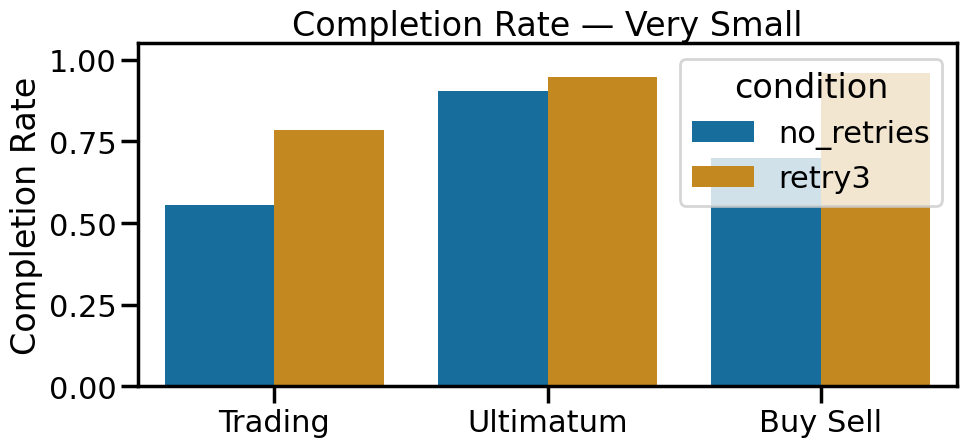

In [5]:
plot_completion("very_small")

### Small

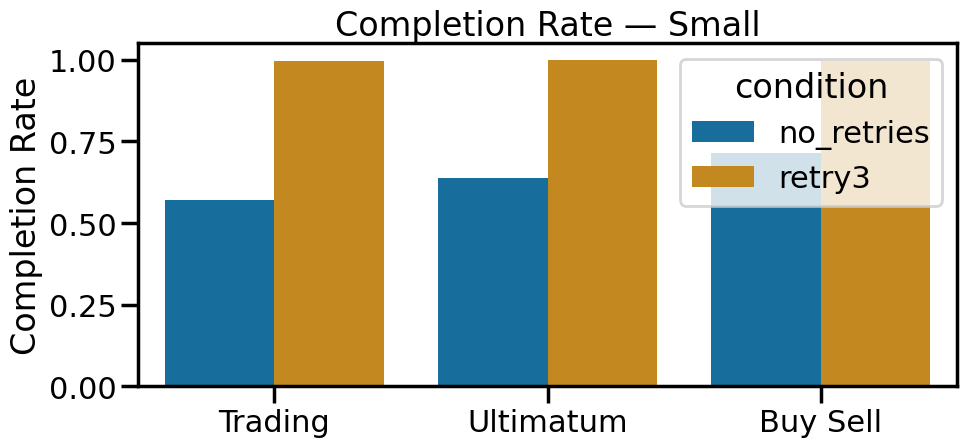

In [6]:
plot_completion("small")

### Medium

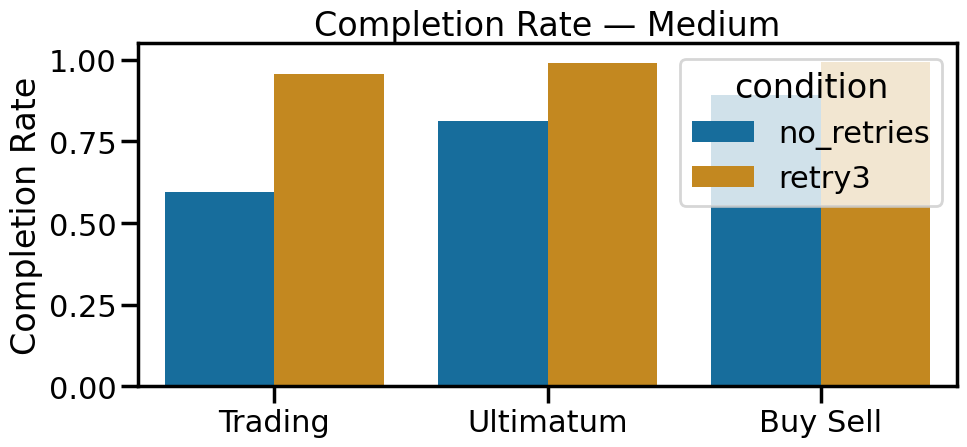

In [7]:
plot_completion("medium")

---
## Retry 3

### Very Small

#### Trading

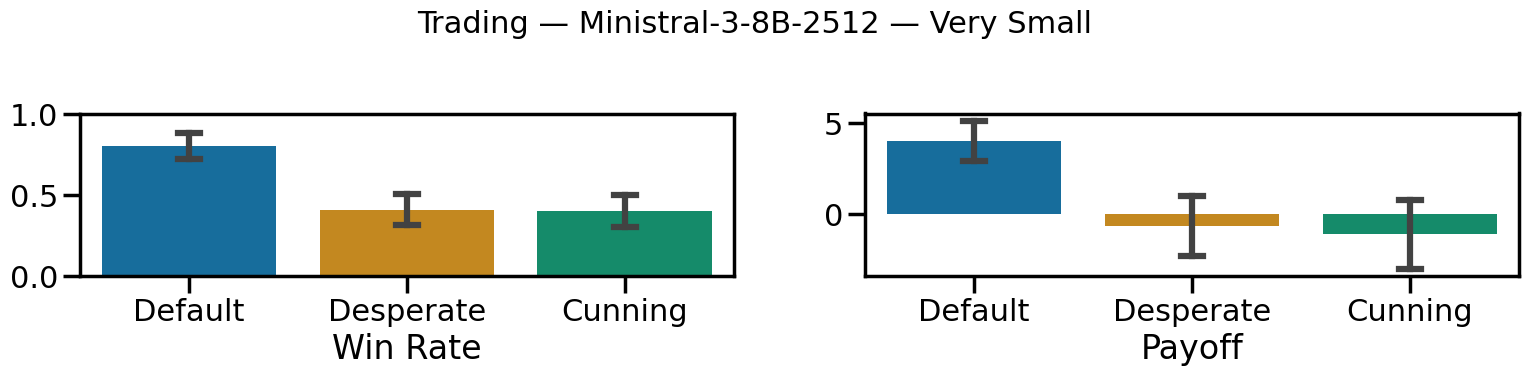

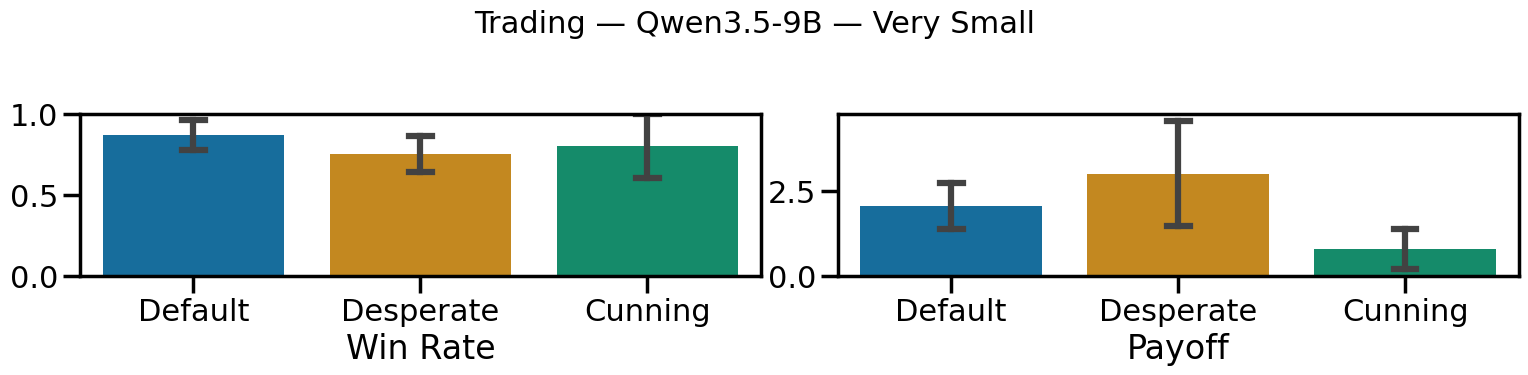

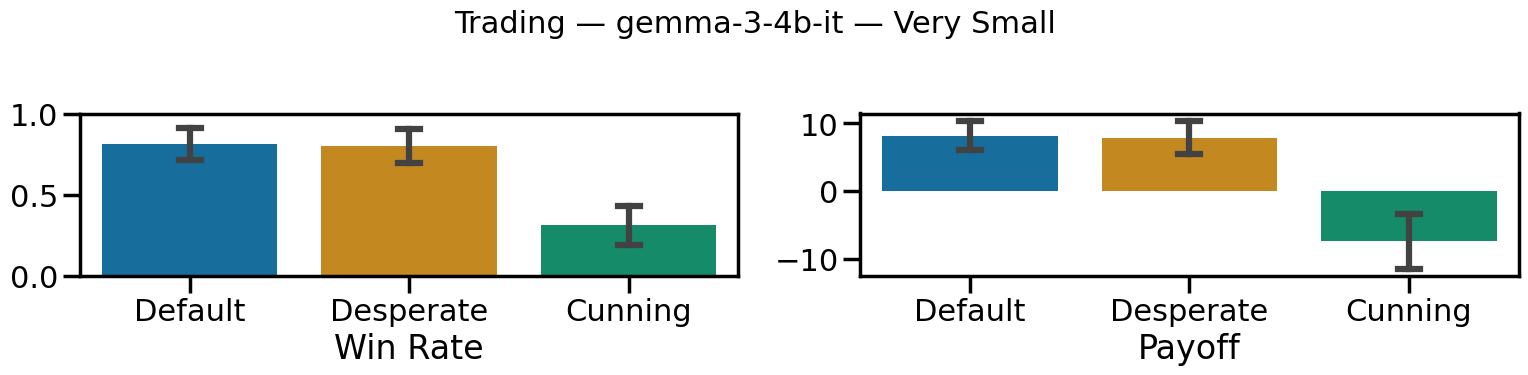

In [8]:
plot_behavior_bars(load_trading("very_small", retry=True), "win_2", "resource_delta_2", "Trading", "Very Small")

#### Ultimatum

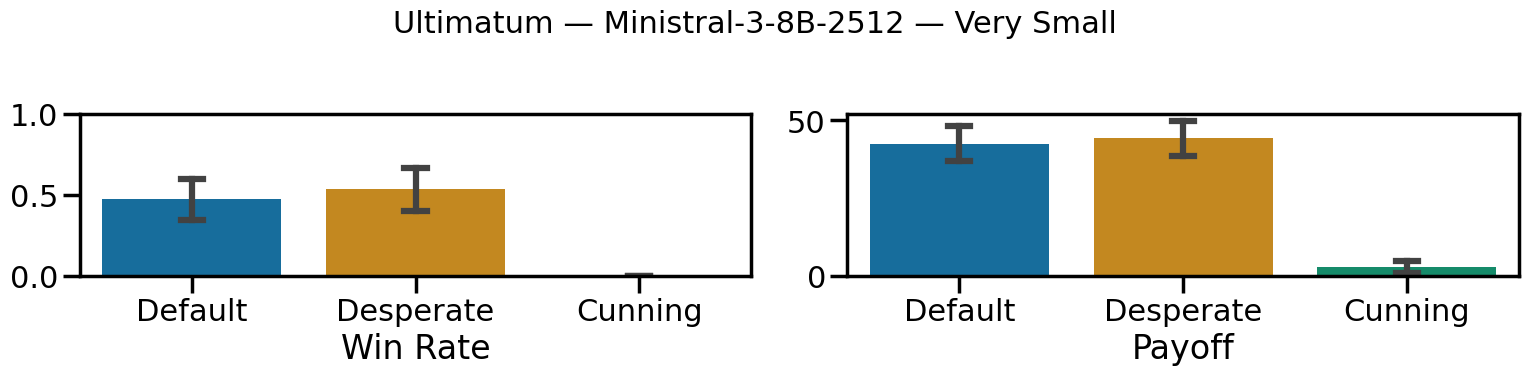

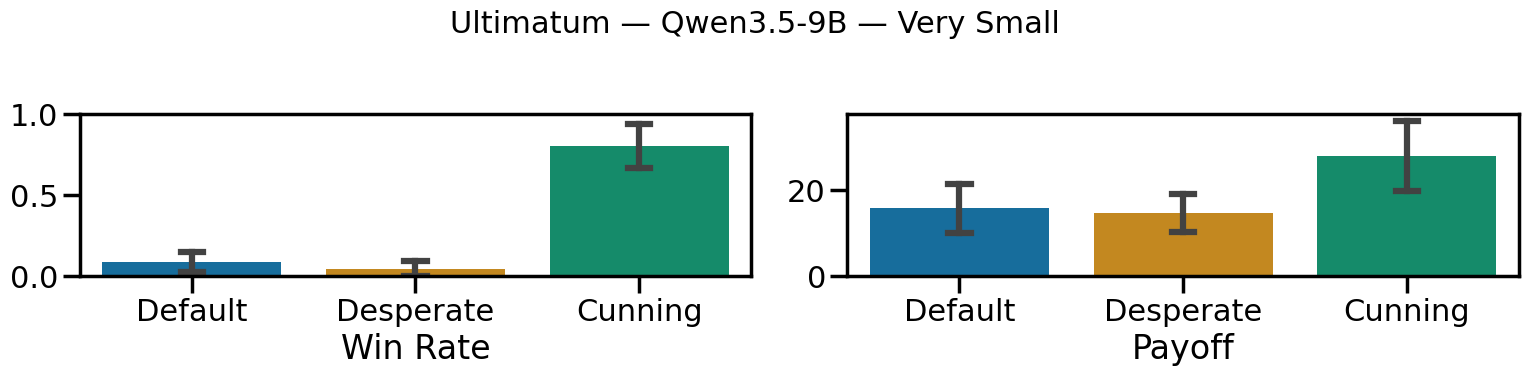

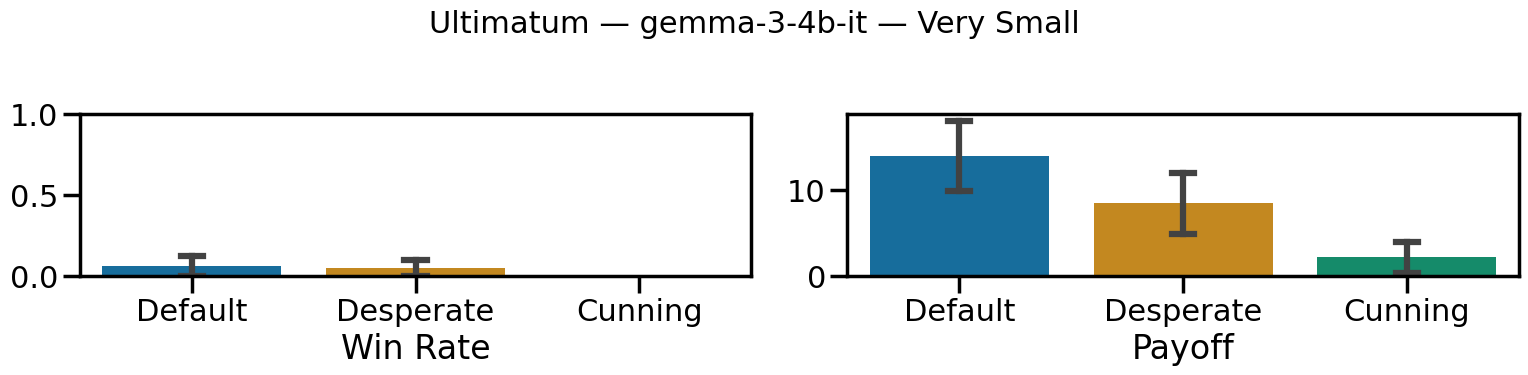

In [9]:
plot_behavior_bars(load_ultimatum("very_small", retry=True), "win_2", "resource_delta_2", "Ultimatum", "Very Small")

#### Buy Sell

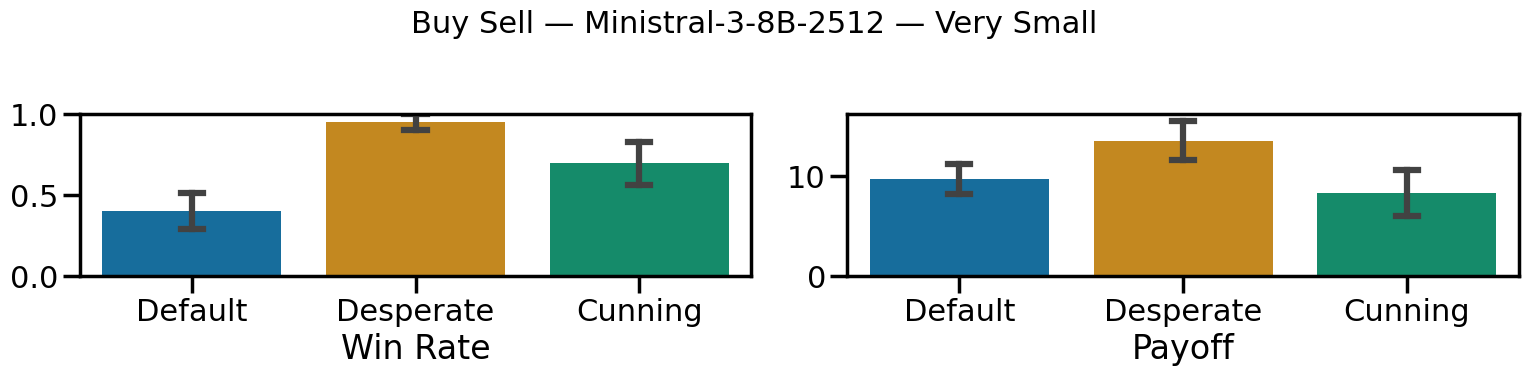

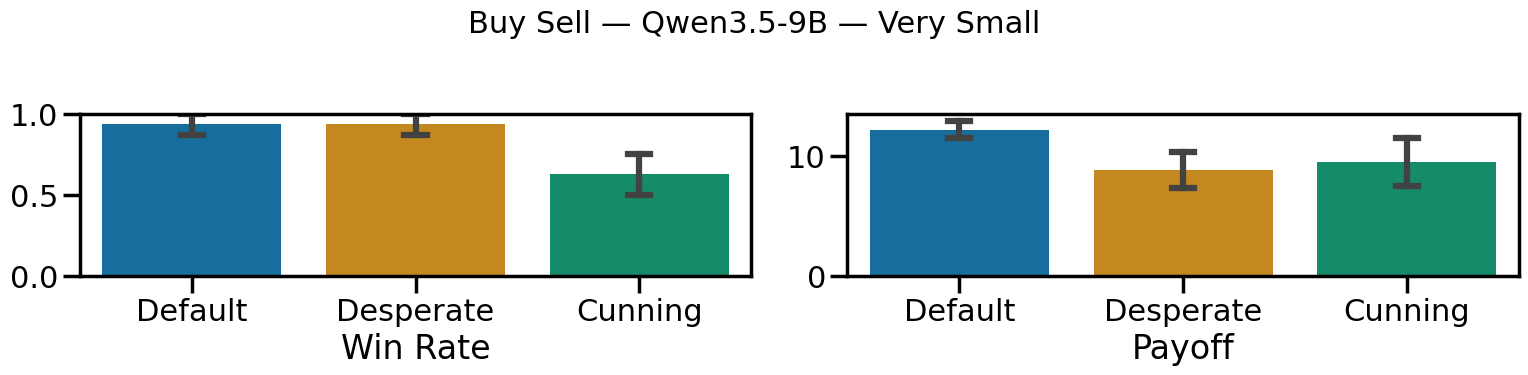

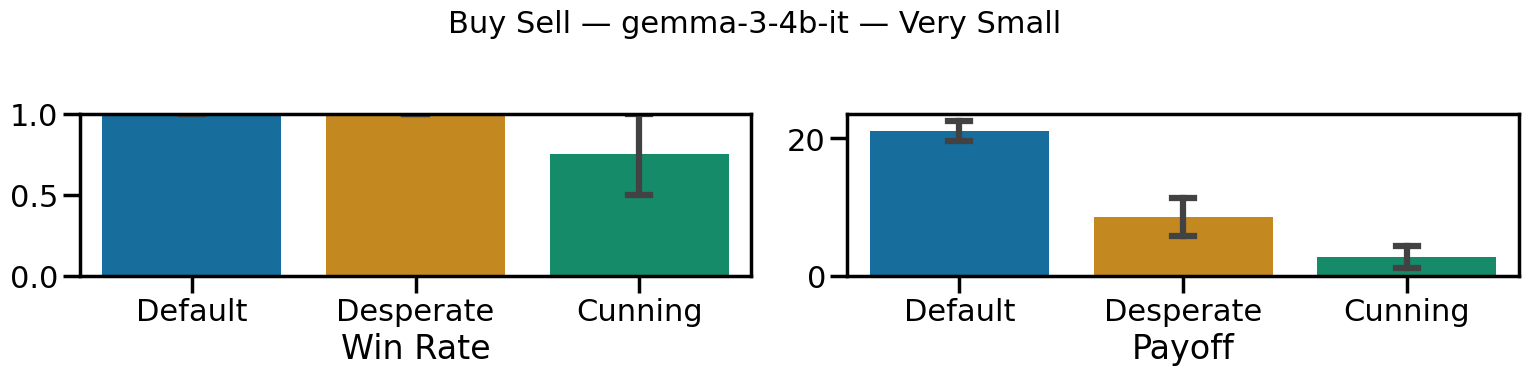

In [10]:
plot_behavior_bars(load_buysell("very_small", retry=True), "win_2", "outcome_2", "Buy Sell", "Very Small")

---
### Small

#### Trading

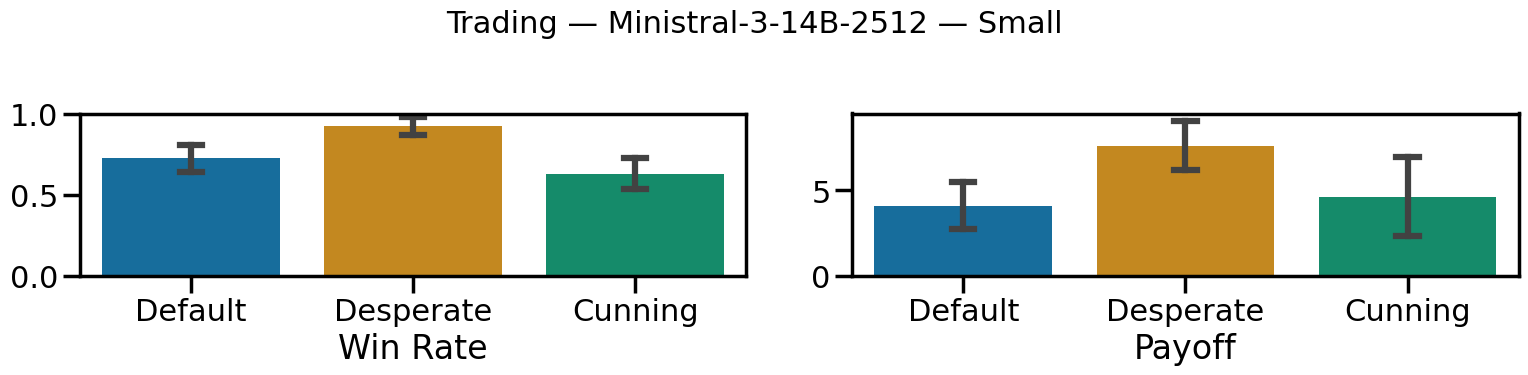

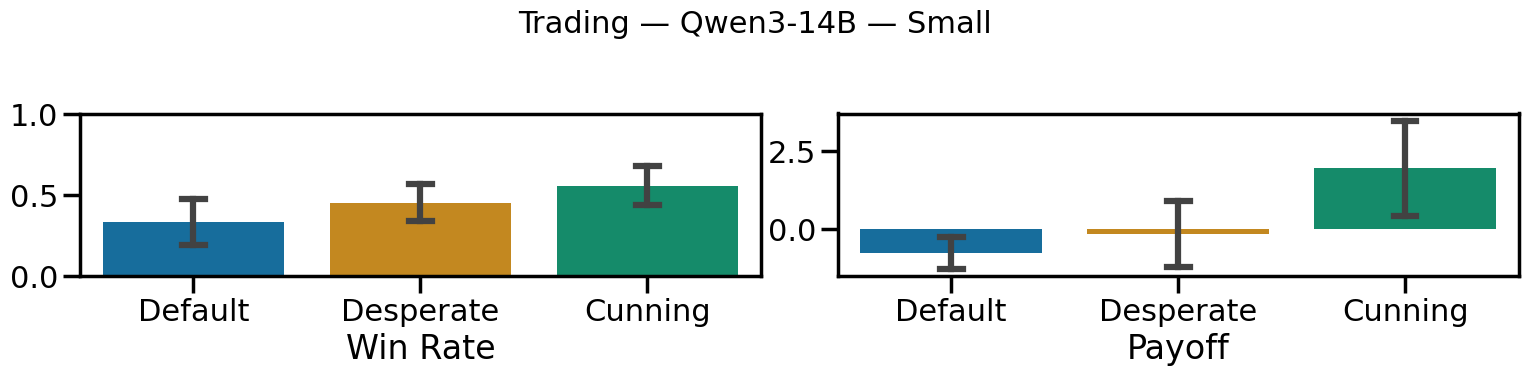

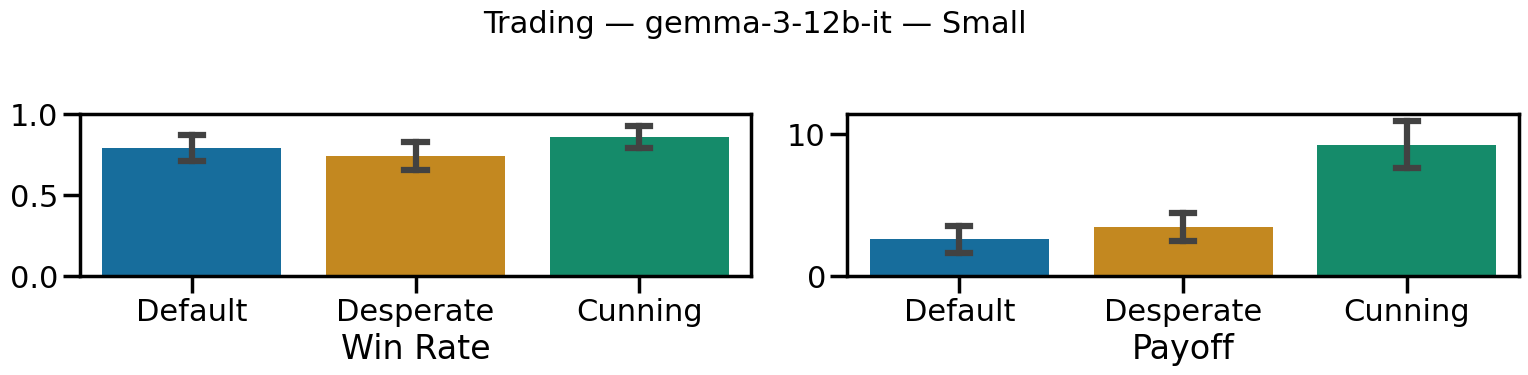

In [11]:
plot_behavior_bars(load_trading("small", retry=True), "win_2", "resource_delta_2", "Trading", "Small")

#### Ultimatum

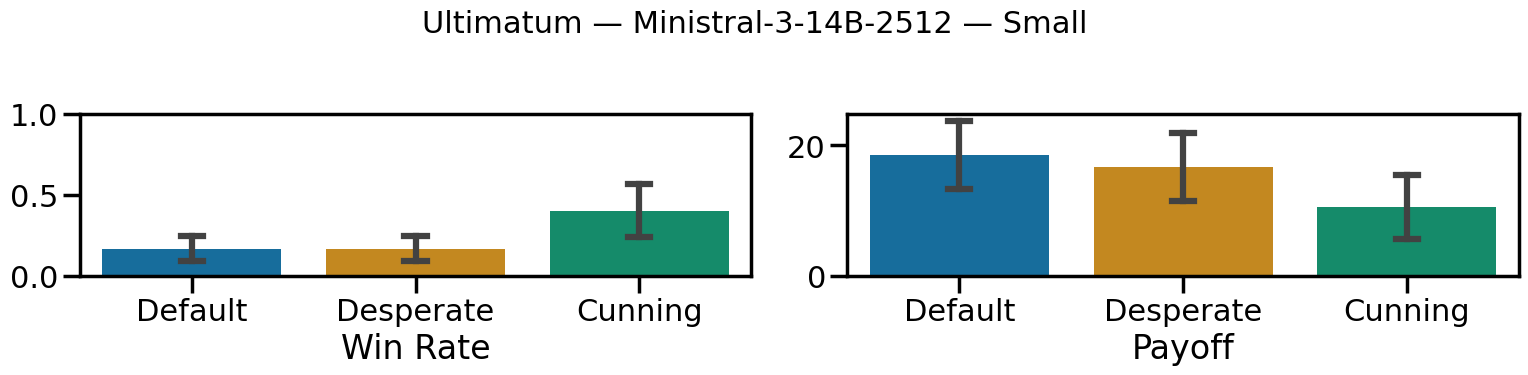

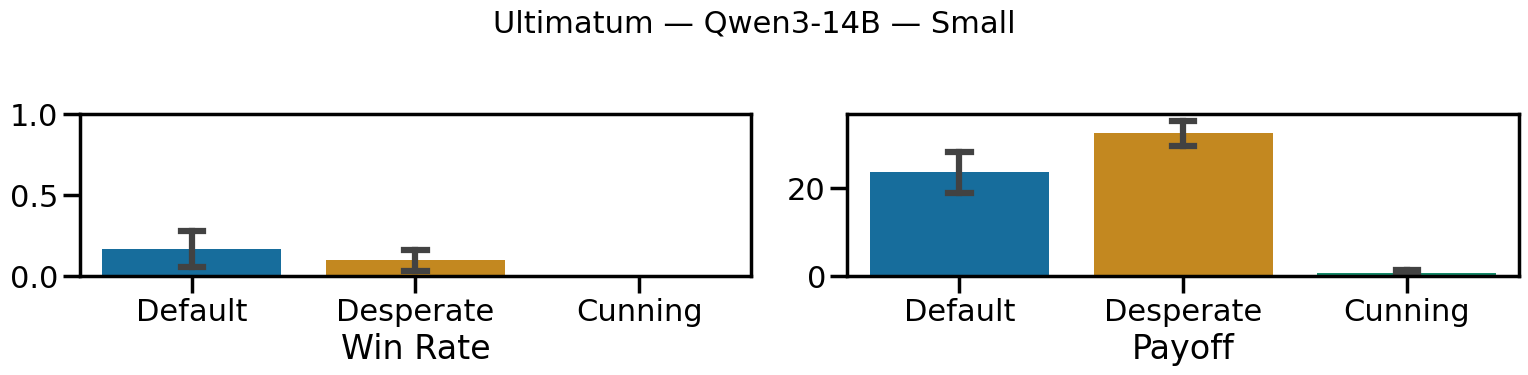

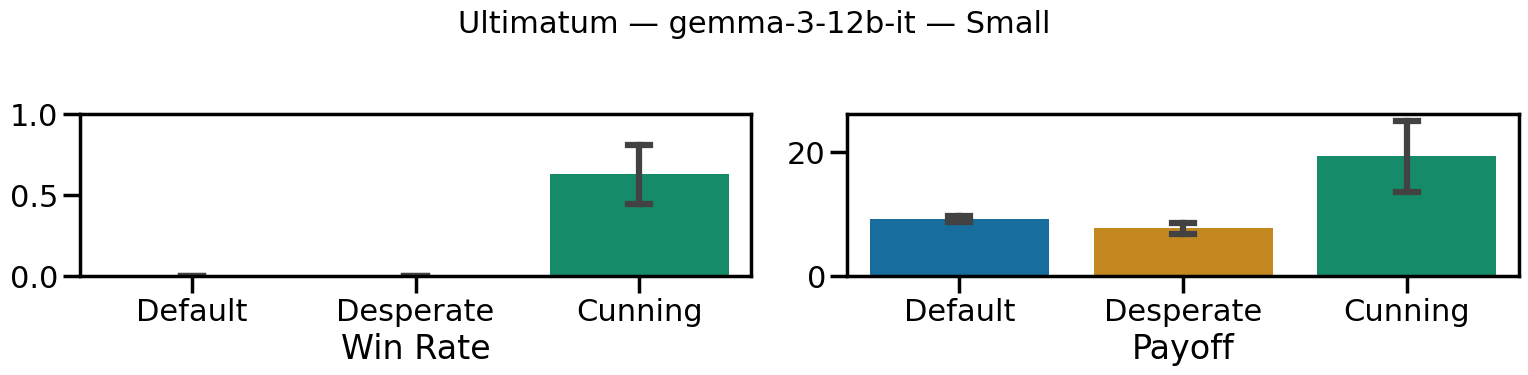

In [12]:
plot_behavior_bars(load_ultimatum("small", retry=True), "win_2", "resource_delta_2", "Ultimatum", "Small")

#### Buy Sell

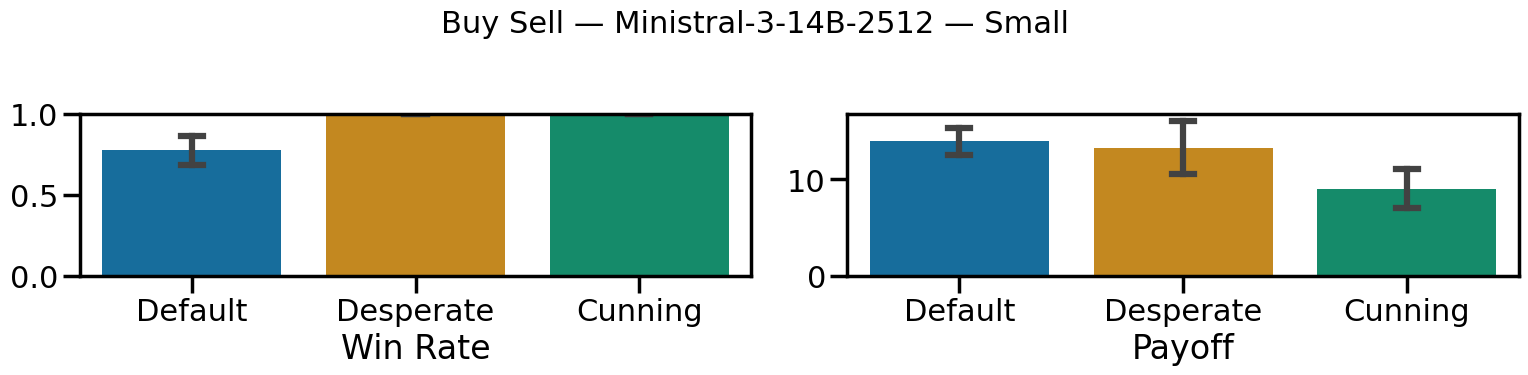

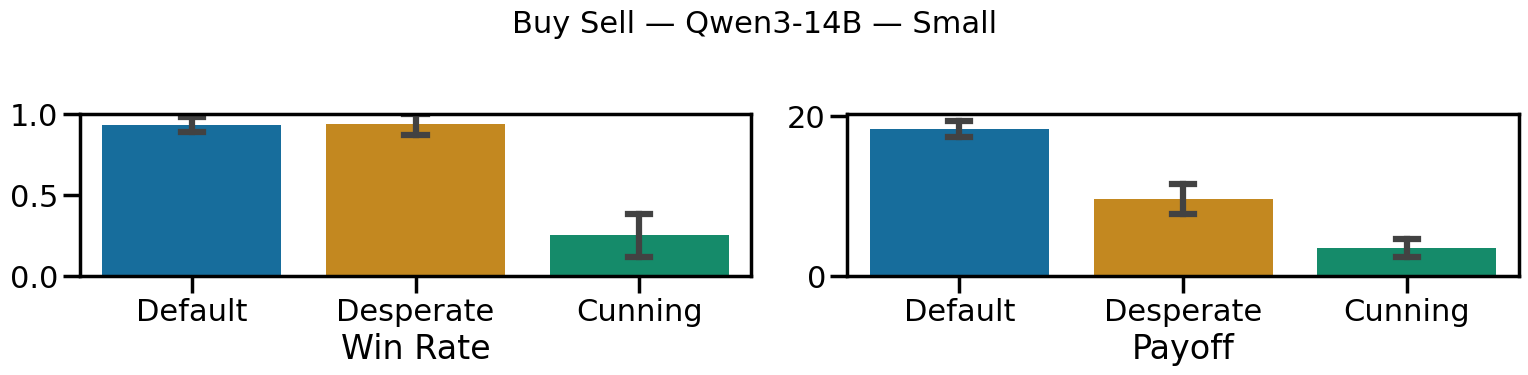

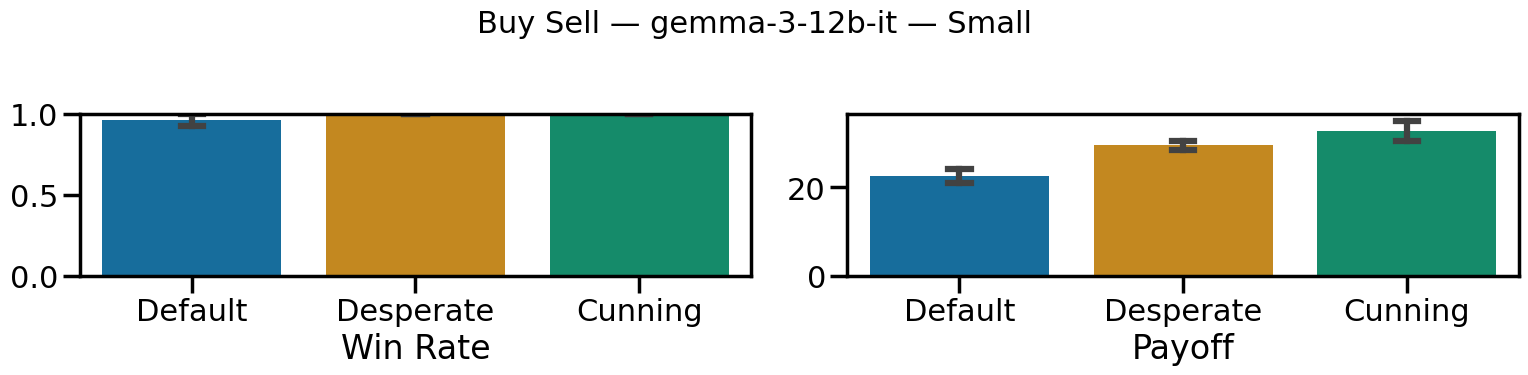

In [13]:
plot_behavior_bars(load_buysell("small", retry=True), "win_2", "outcome_2", "Buy Sell", "Small")

---
### Medium

#### Trading

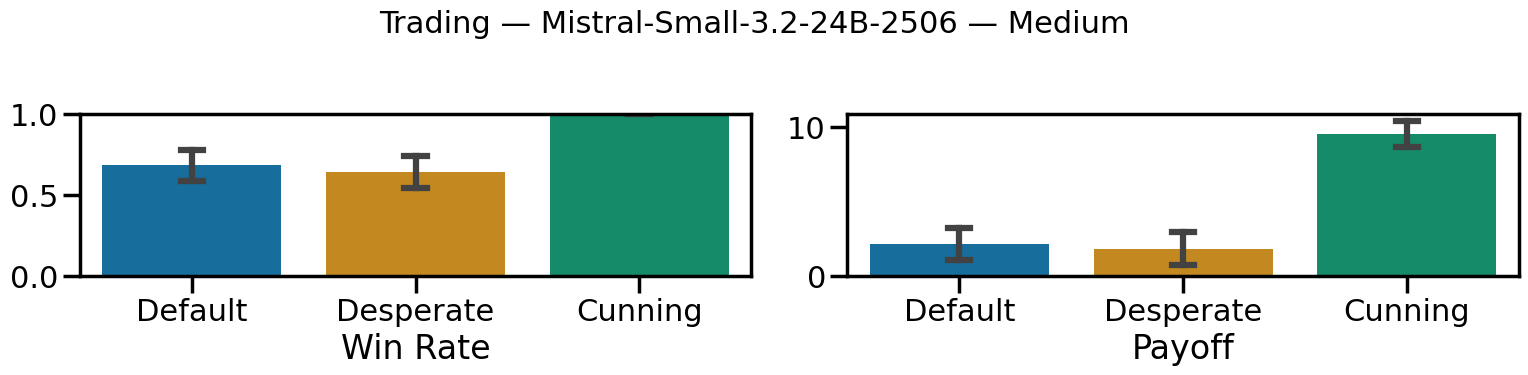

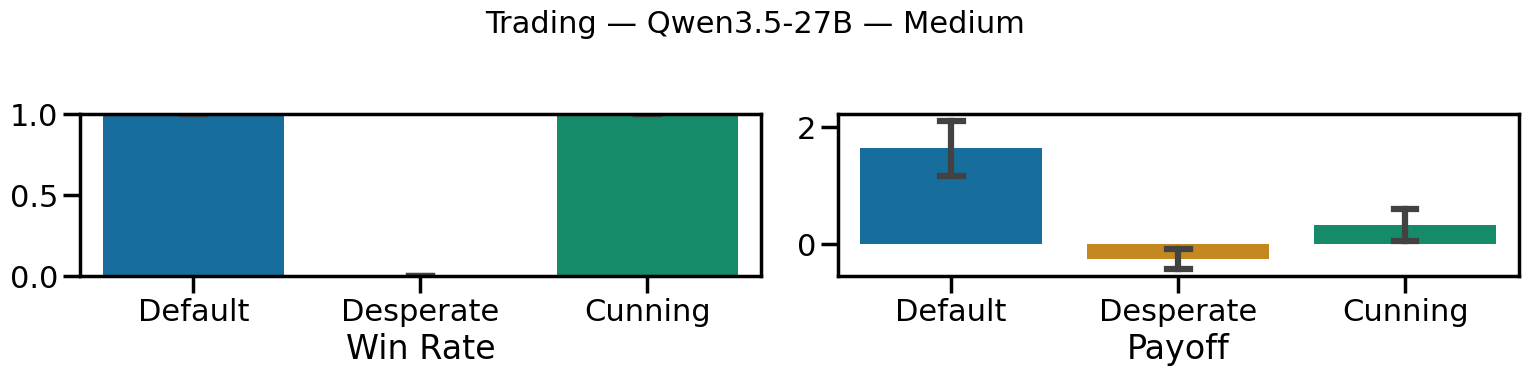

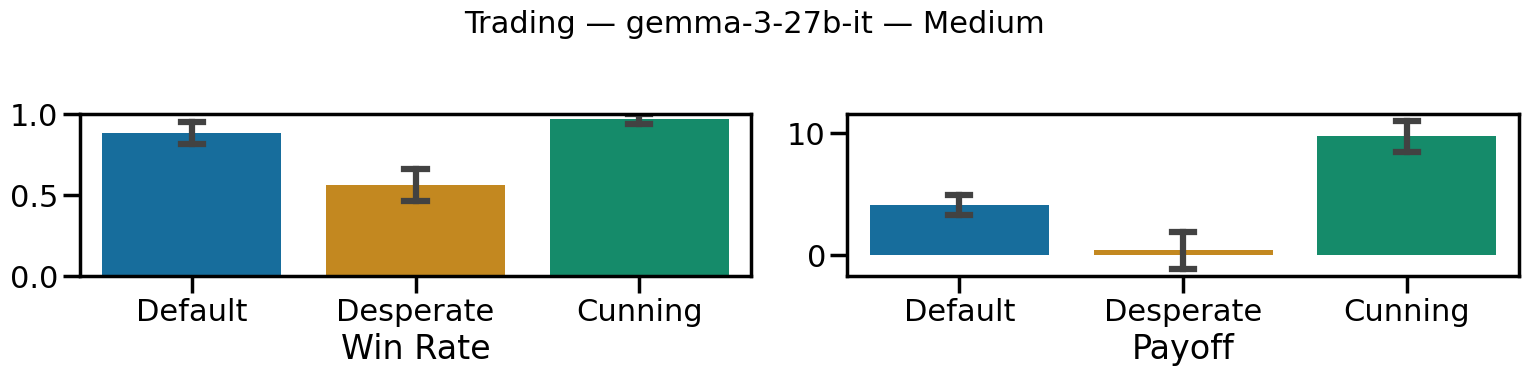

In [14]:
plot_behavior_bars(load_trading("medium", retry=True), "win_2", "resource_delta_2", "Trading", "Medium")

#### Ultimatum

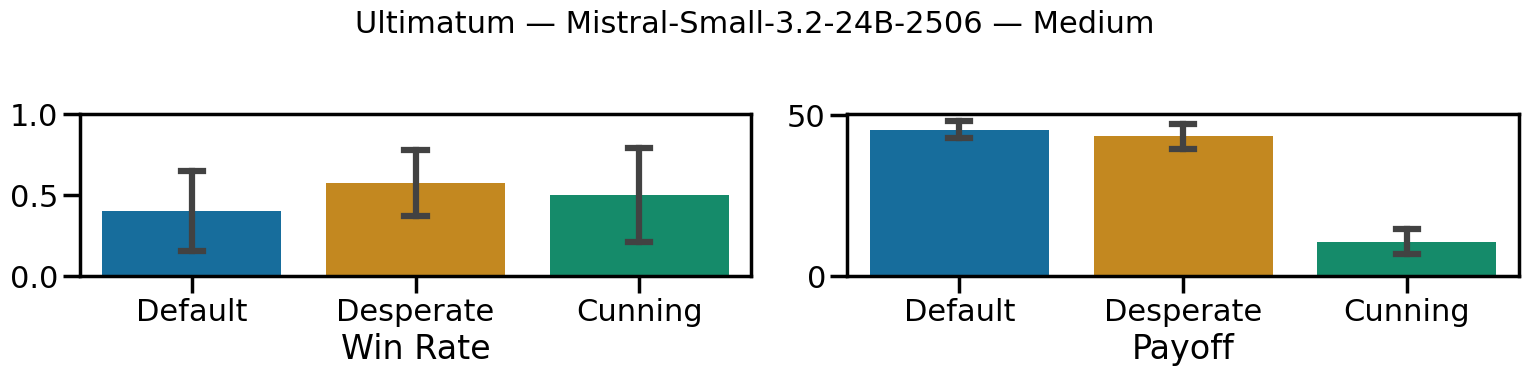

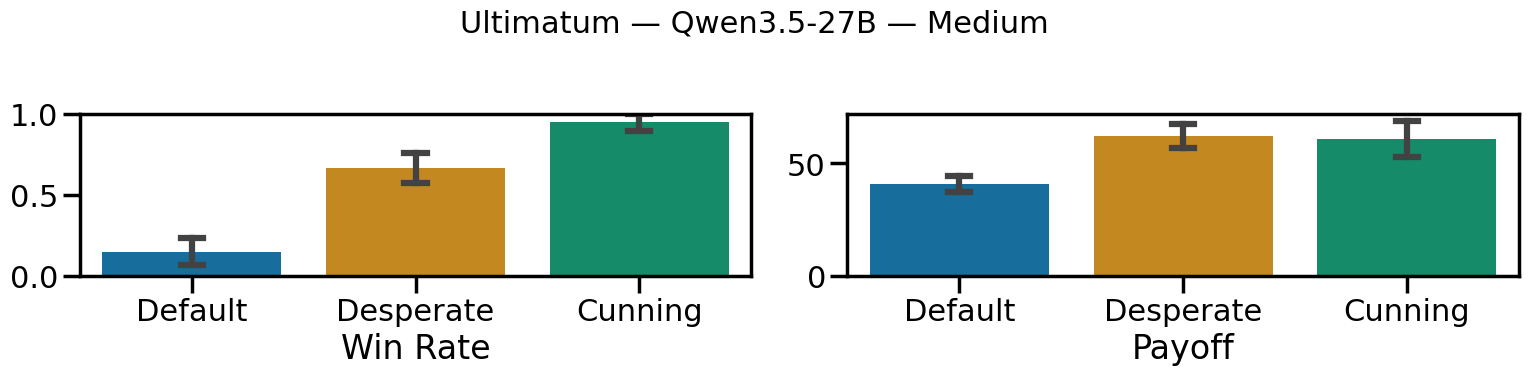

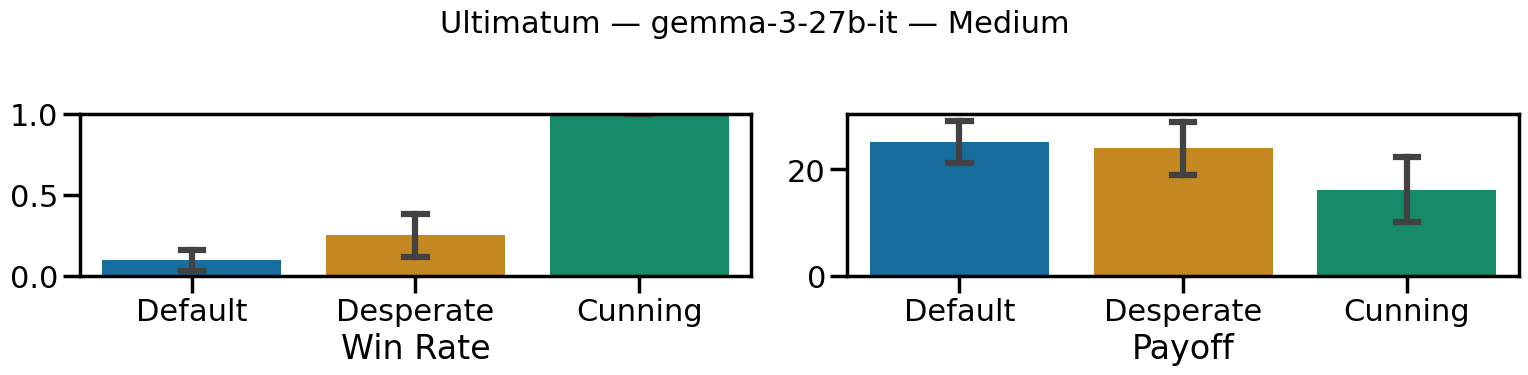

In [15]:
plot_behavior_bars(load_ultimatum("medium", retry=True), "win_2", "resource_delta_2", "Ultimatum", "Medium")

#### Buy Sell

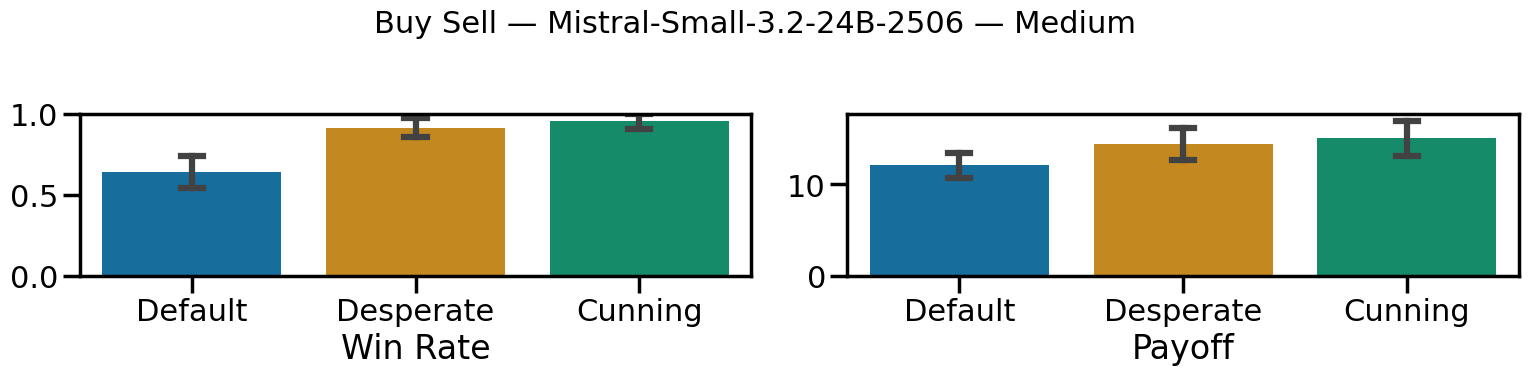

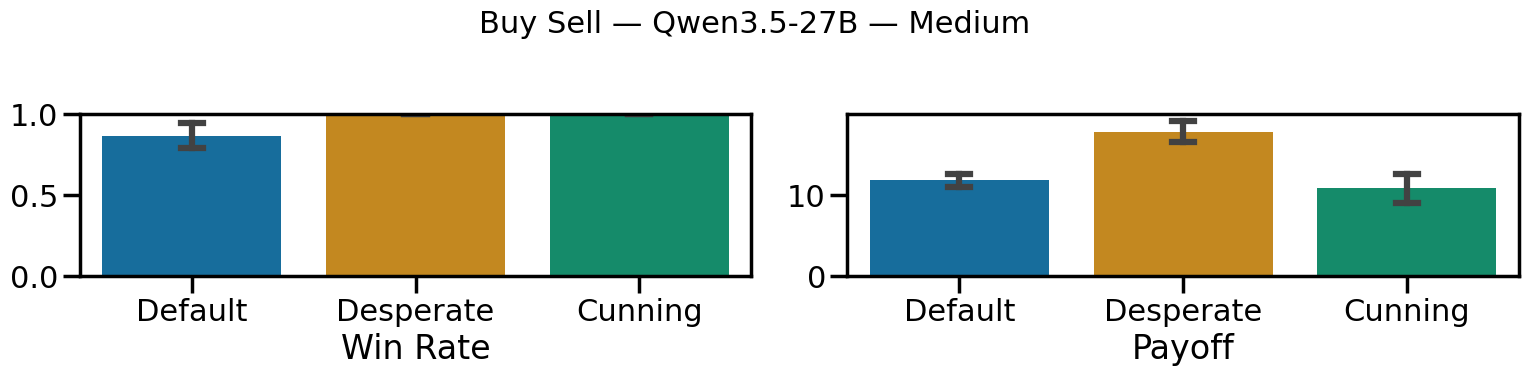

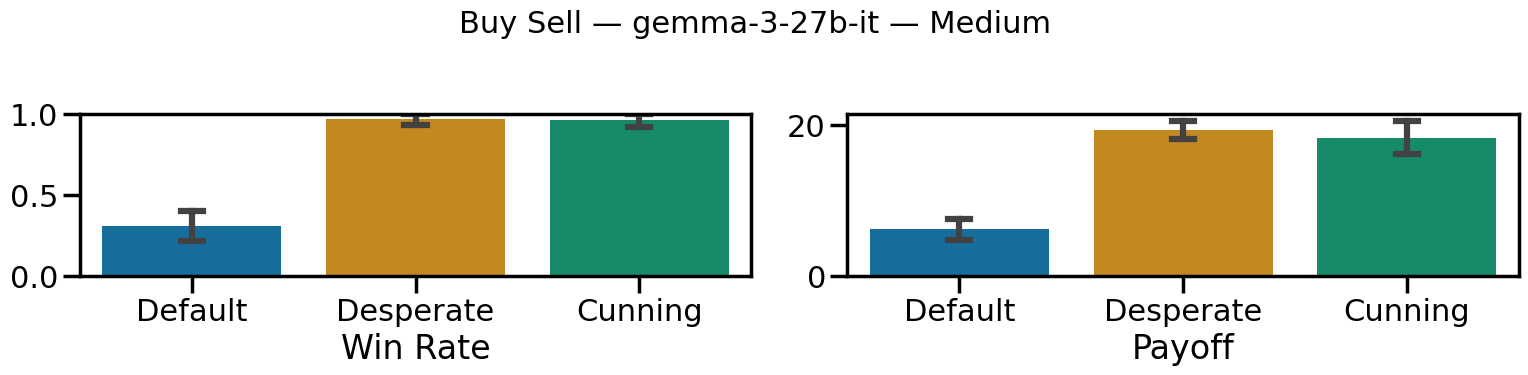

In [16]:
plot_behavior_bars(load_buysell("medium", retry=True), "win_2", "outcome_2", "Buy Sell", "Medium")

---
## No Retries

### Very Small

#### Trading

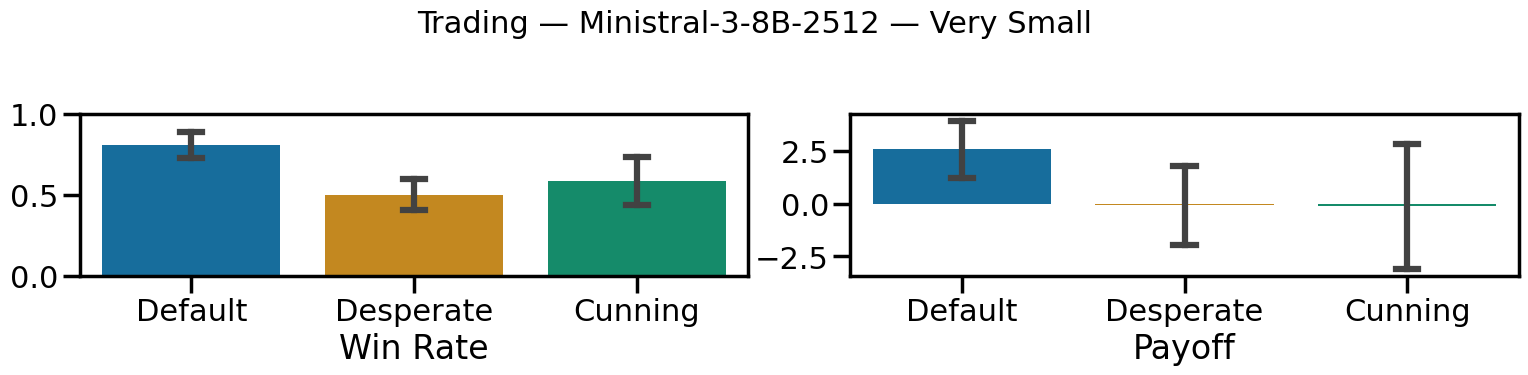

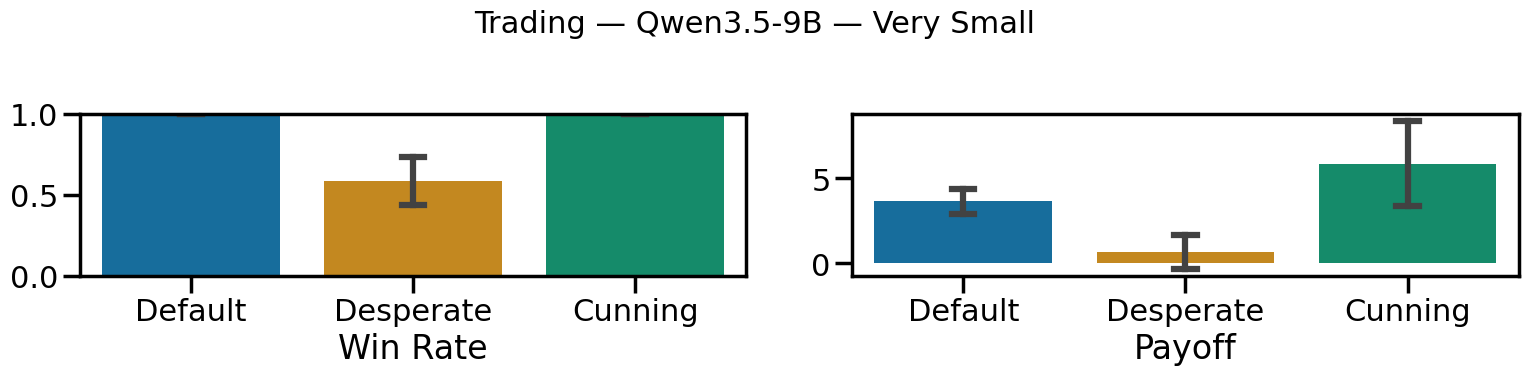

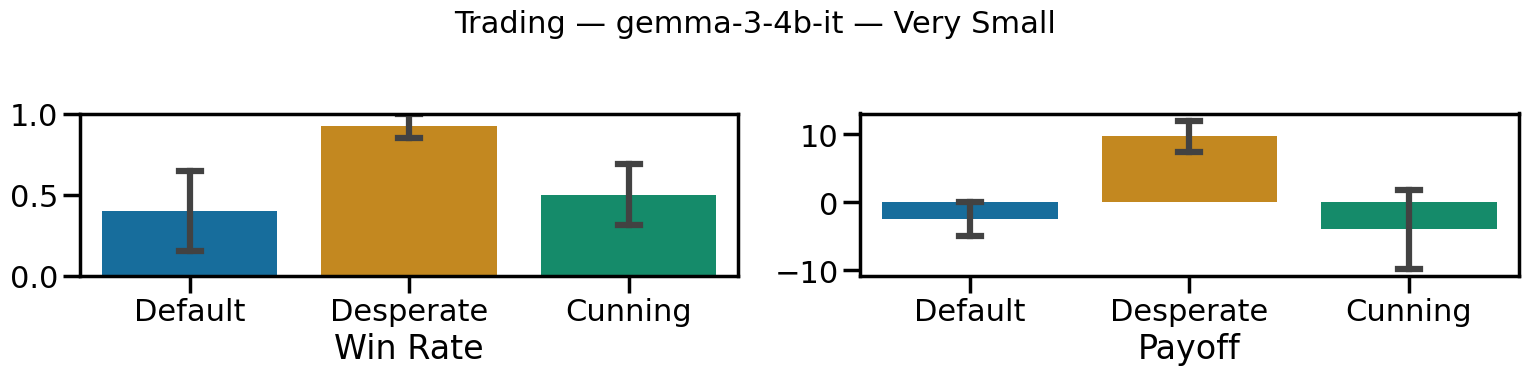

In [17]:
plot_behavior_bars(load_trading("very_small"), "win_2", "resource_delta_2", "Trading", "Very Small")

#### Ultimatum

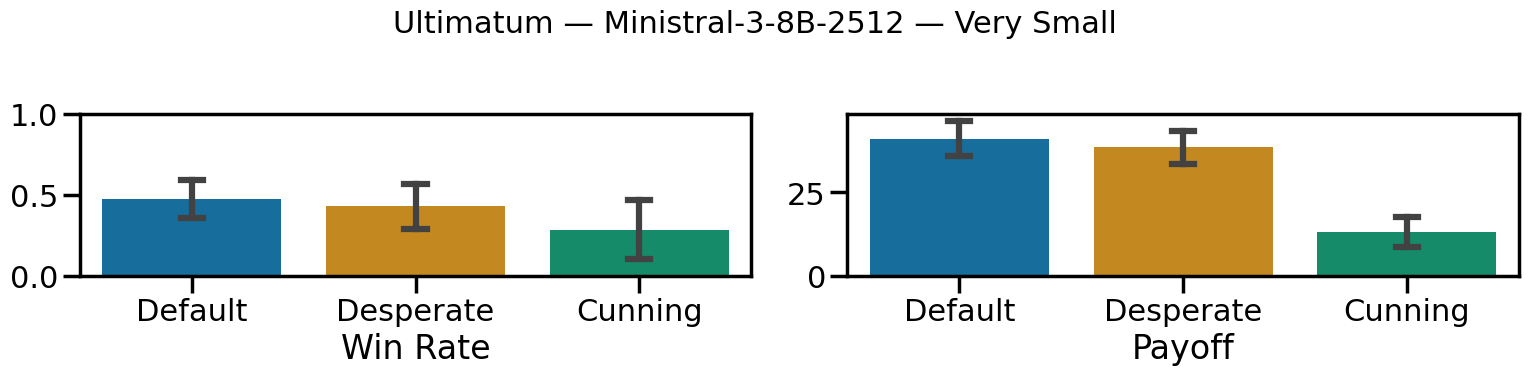

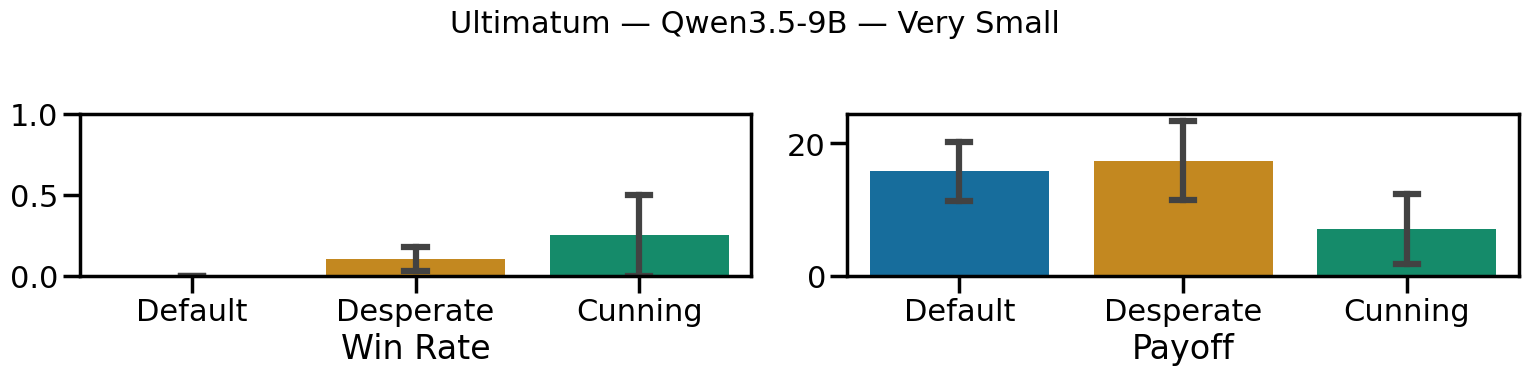

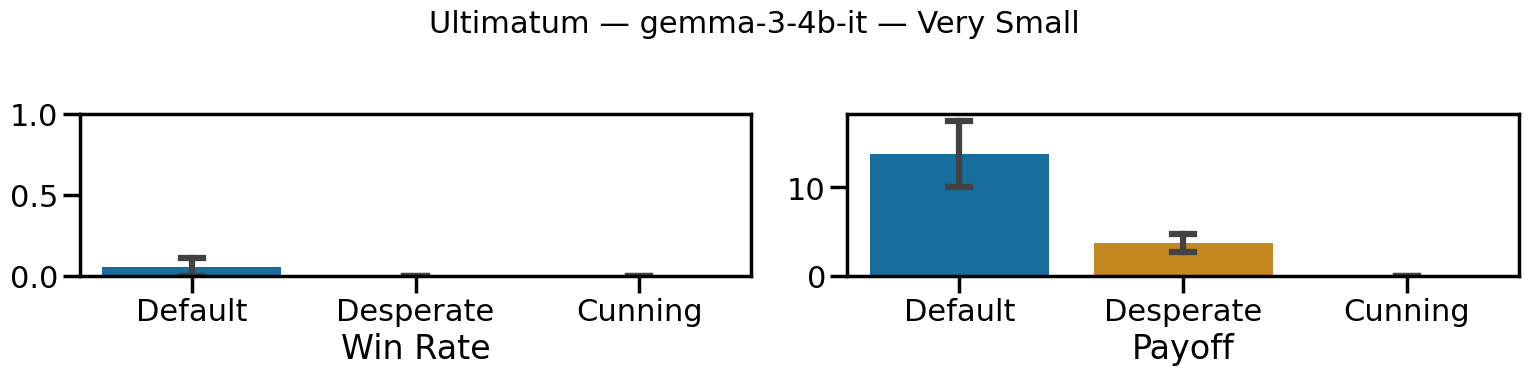

In [18]:
plot_behavior_bars(load_ultimatum("very_small"), "win_2", "resource_delta_2", "Ultimatum", "Very Small")

#### Buy Sell

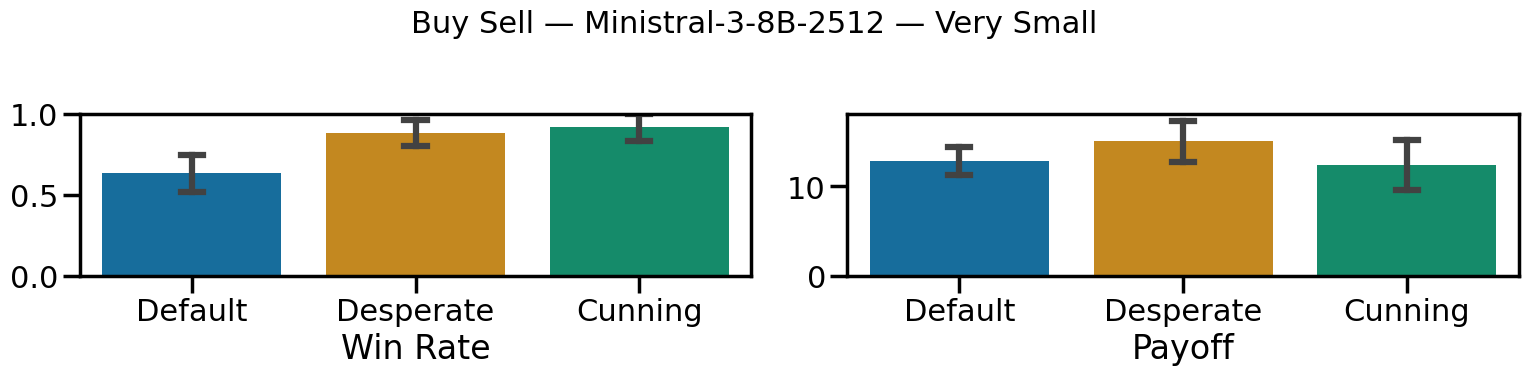

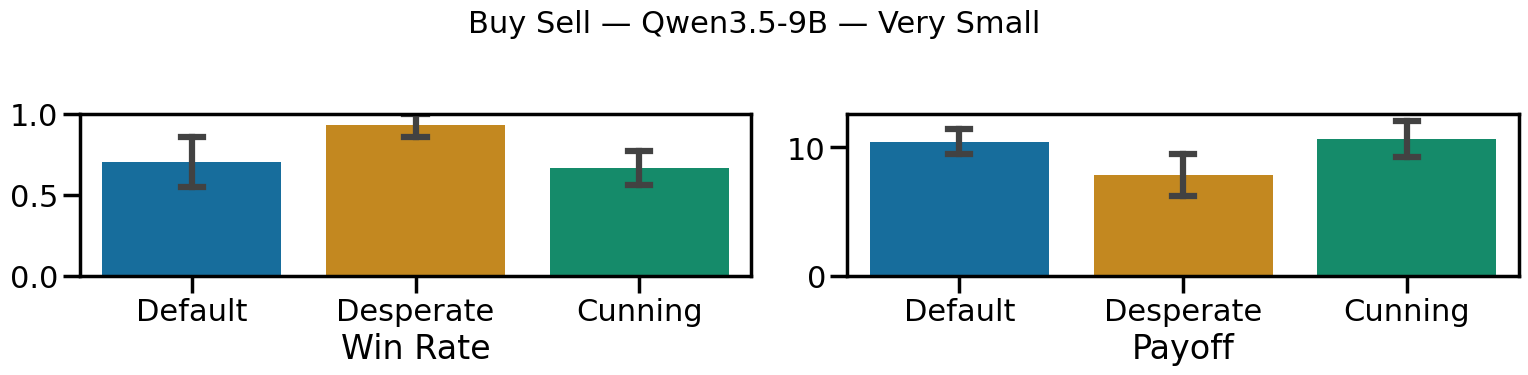

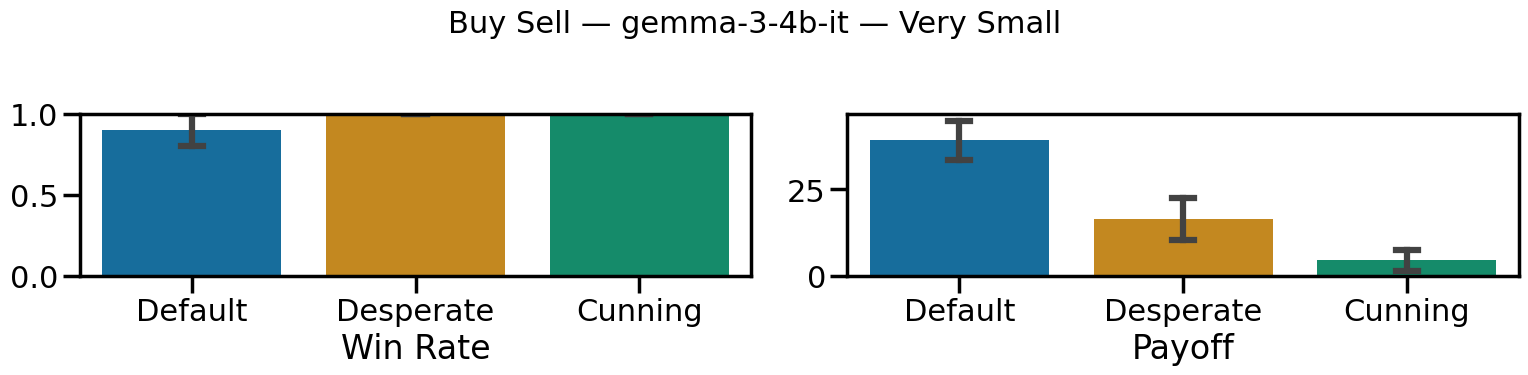

In [19]:
plot_behavior_bars(load_buysell("very_small"), "win_2", "outcome_2", "Buy Sell", "Very Small")

---
### Small

#### Trading

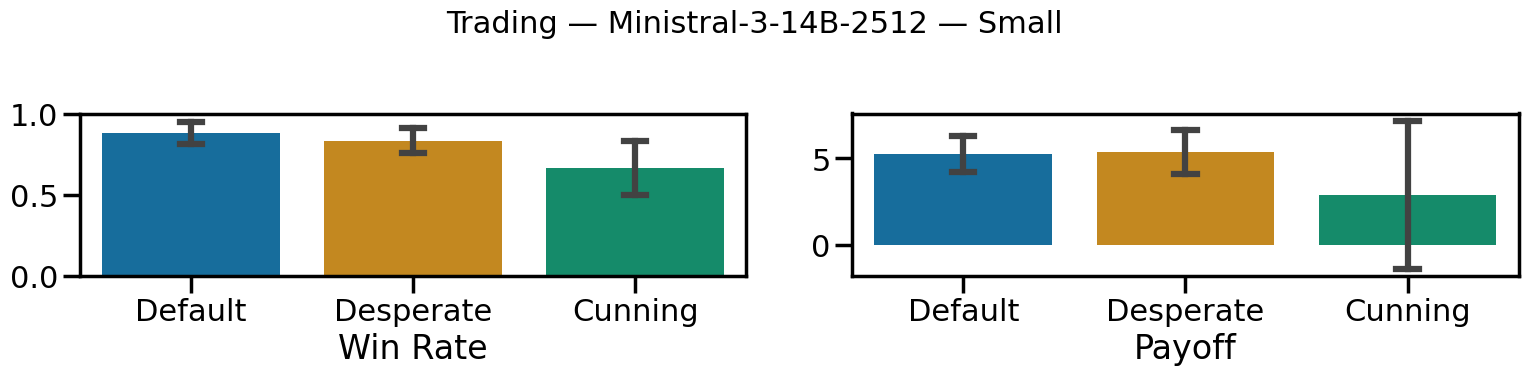

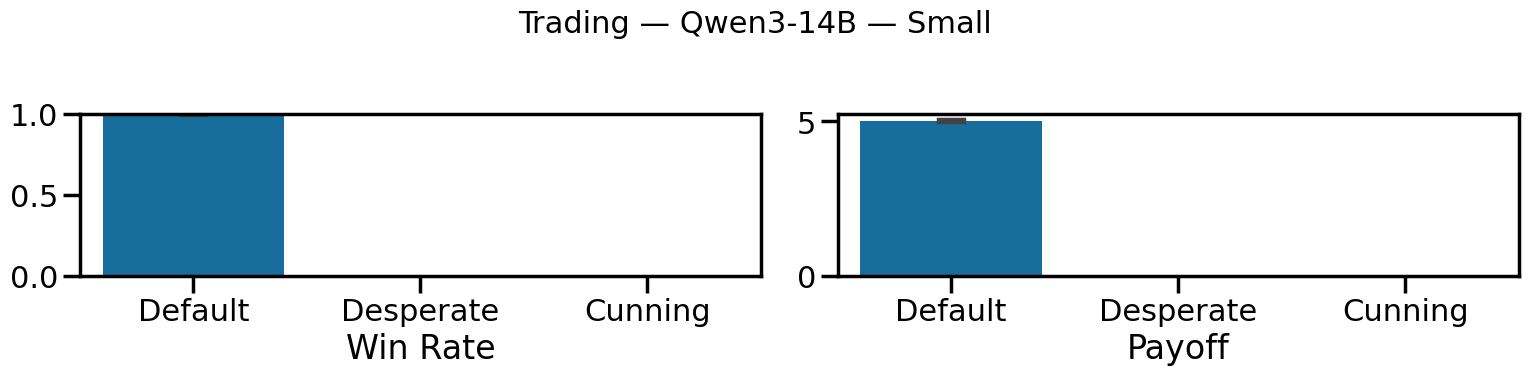

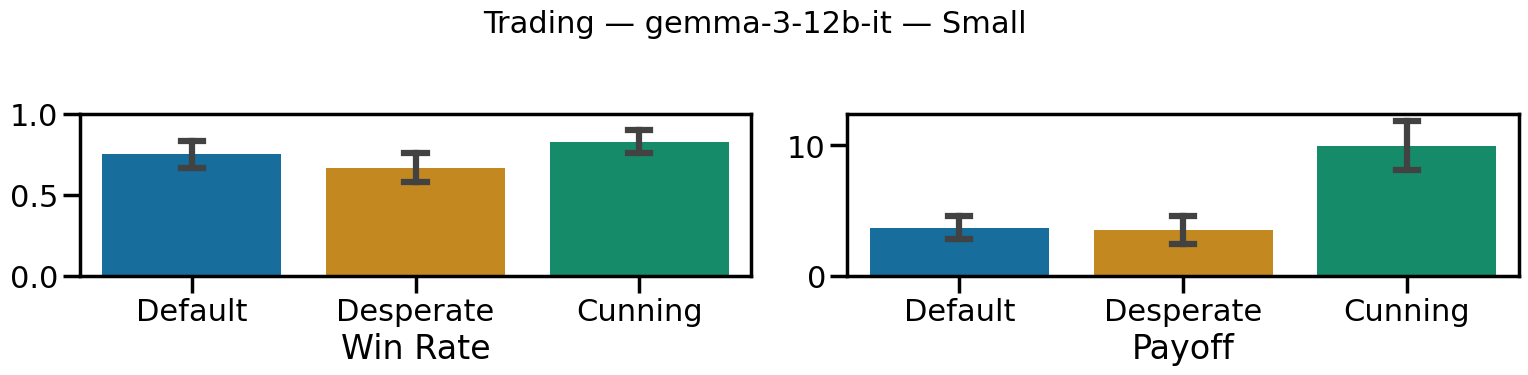

In [20]:
plot_behavior_bars(load_trading("small"), "win_2", "resource_delta_2", "Trading", "Small")

#### Ultimatum

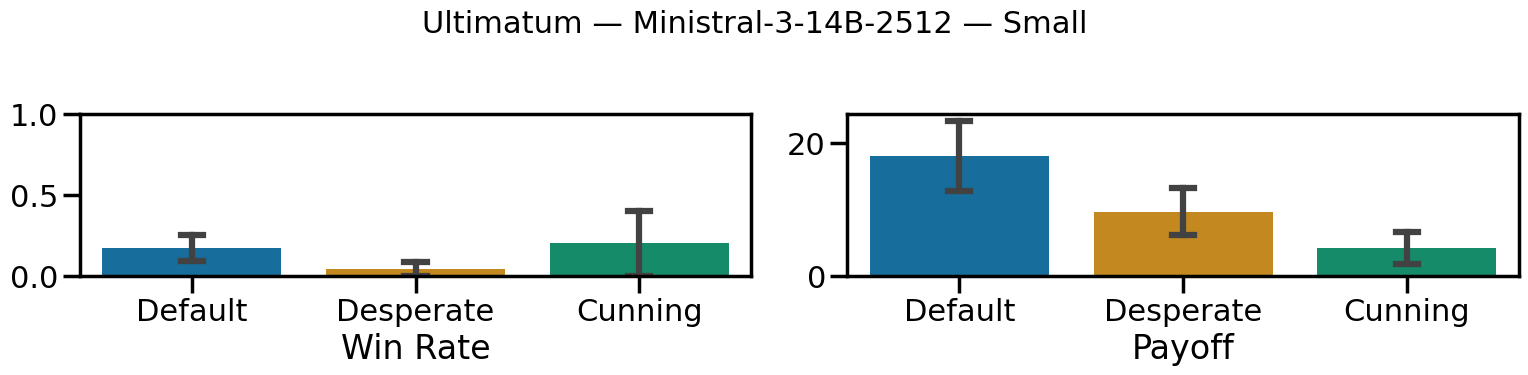

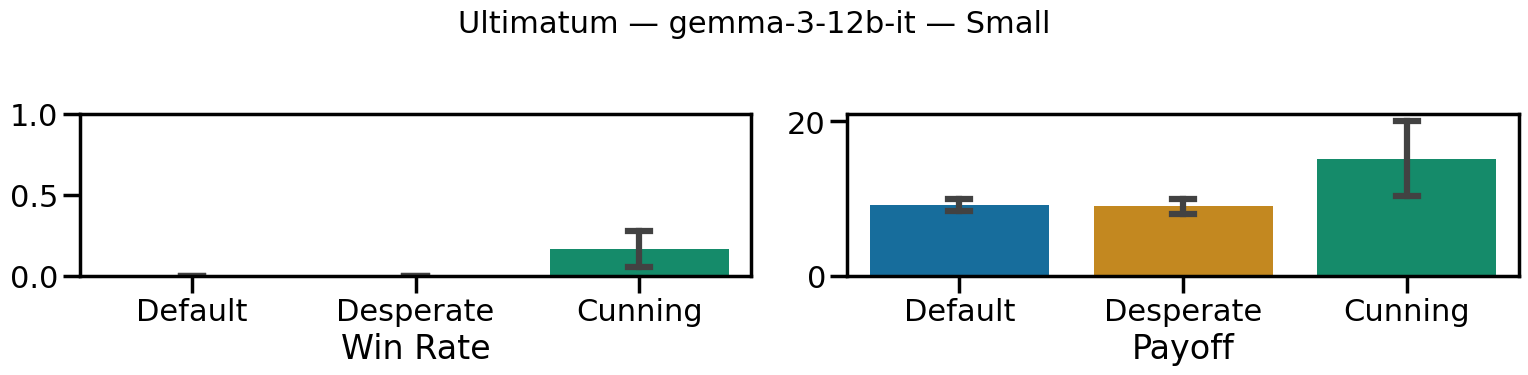

In [21]:
plot_behavior_bars(load_ultimatum("small"), "win_2", "resource_delta_2", "Ultimatum", "Small")

#### Buy Sell

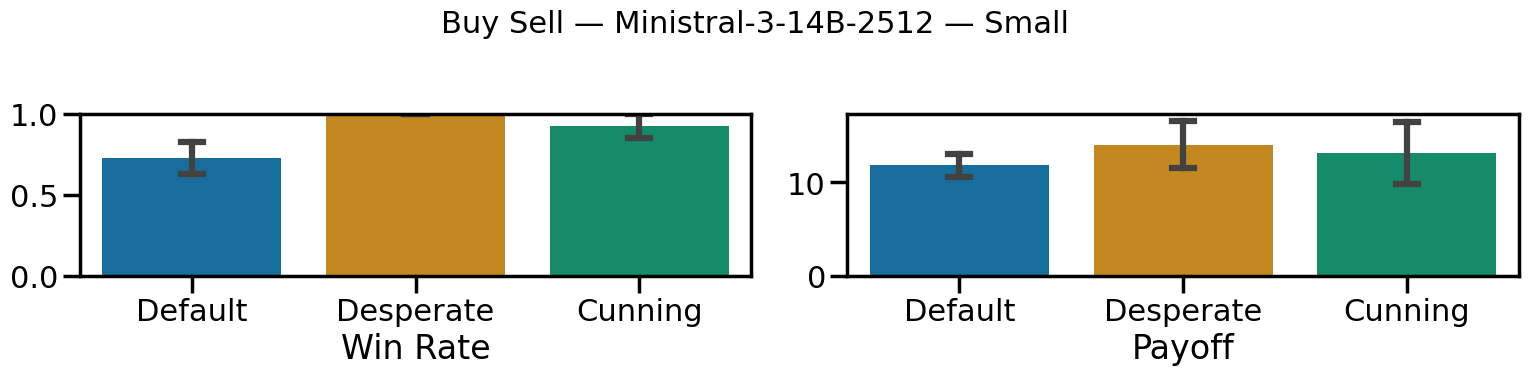

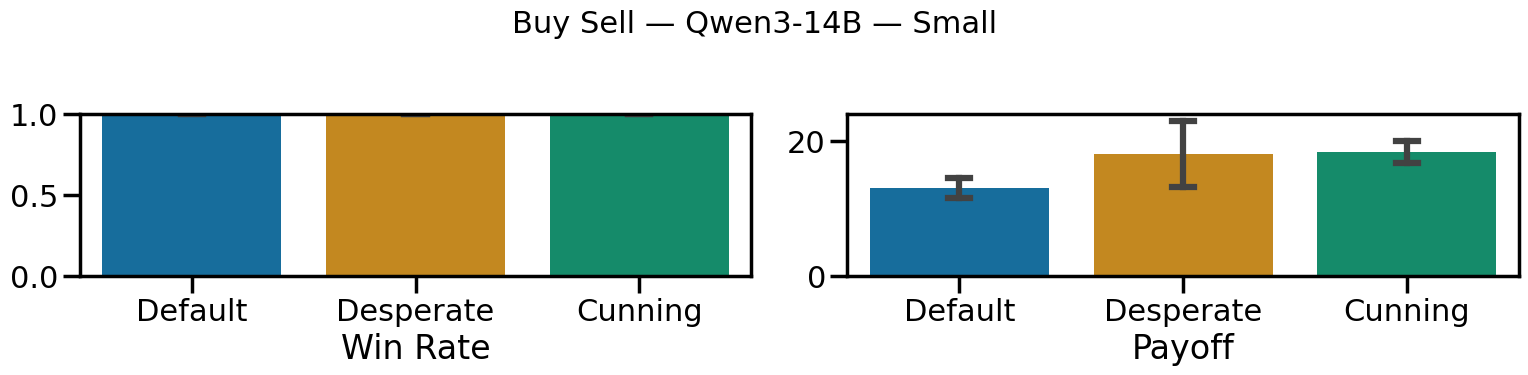

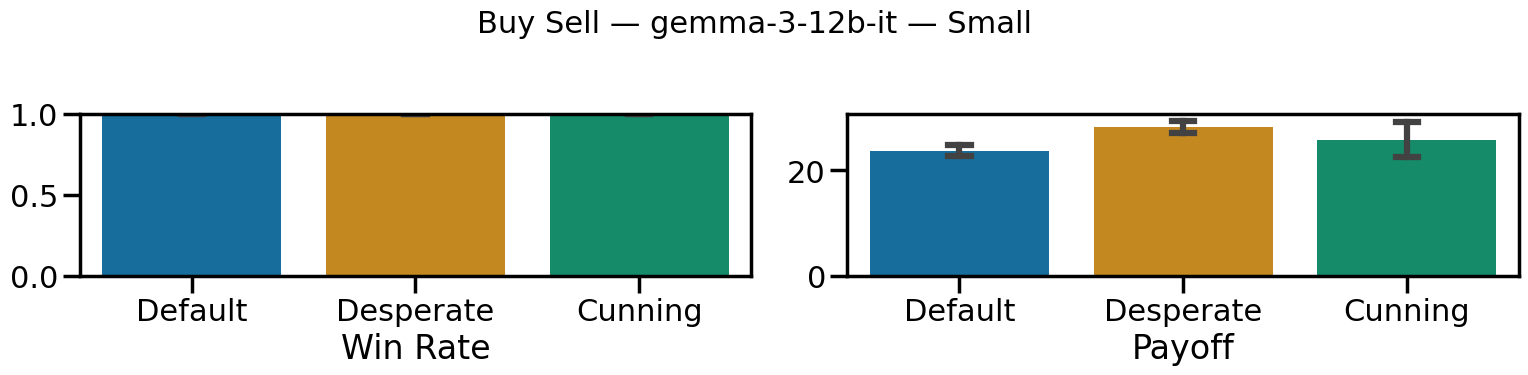

In [22]:
plot_behavior_bars(load_buysell("small"), "win_2", "outcome_2", "Buy Sell", "Small")

---
### Medium

#### Trading

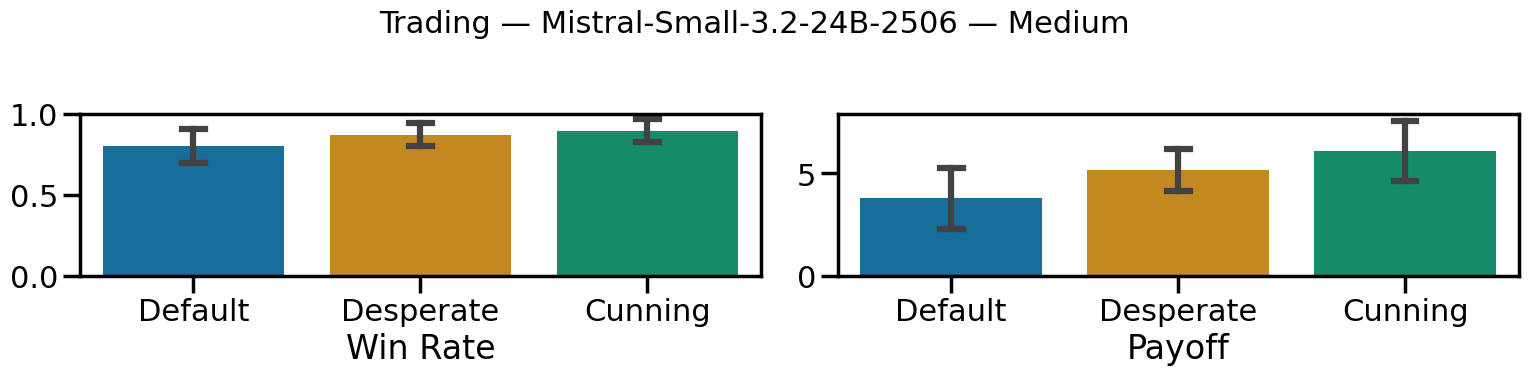

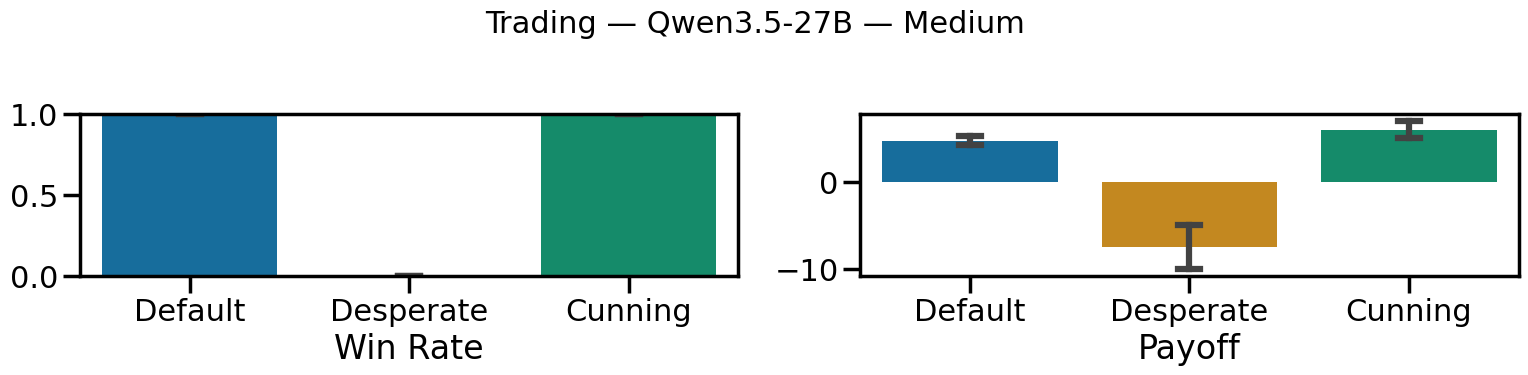

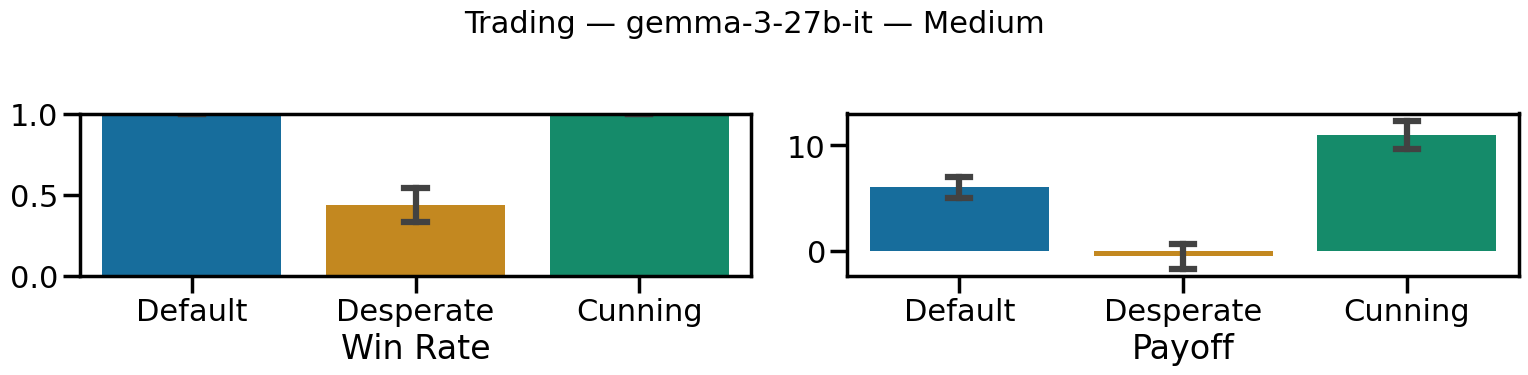

In [23]:
plot_behavior_bars(load_trading("medium"), "win_2", "resource_delta_2", "Trading", "Medium")

#### Ultimatum

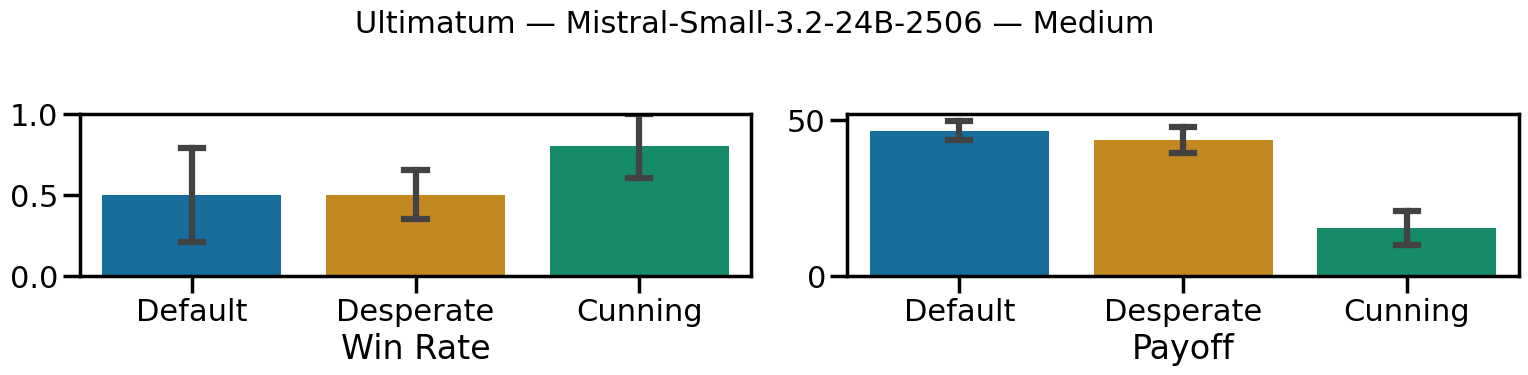

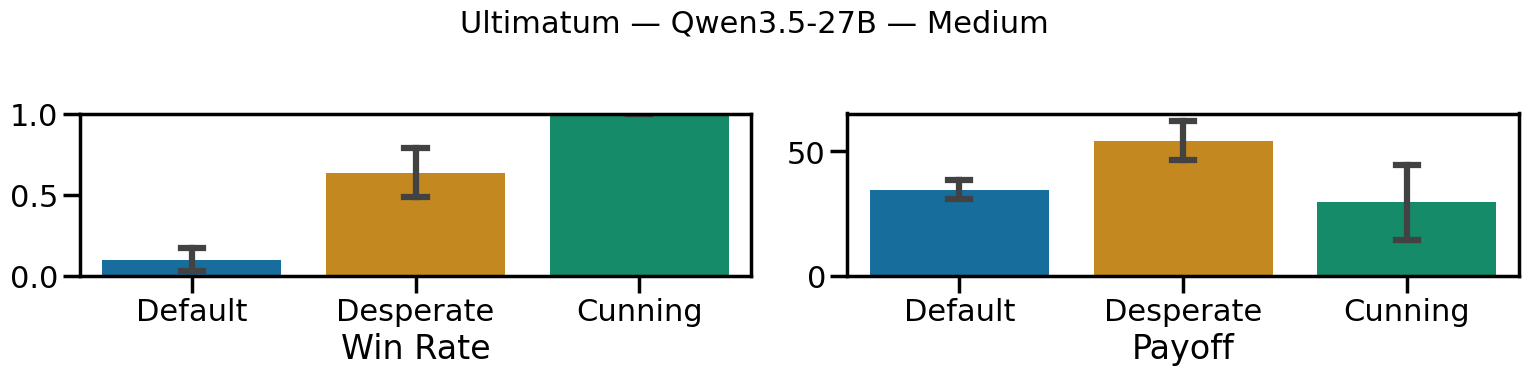

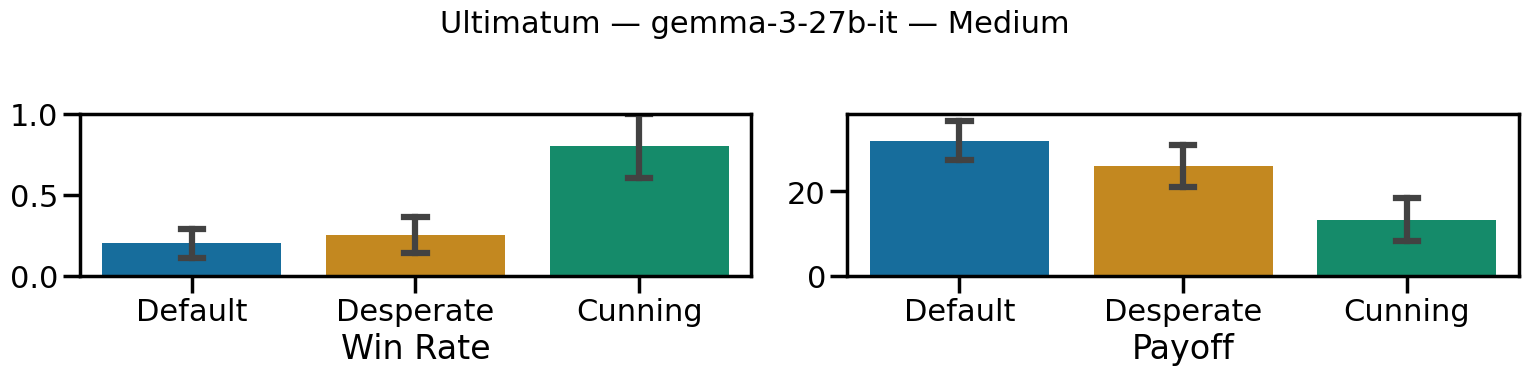

In [24]:
plot_behavior_bars(load_ultimatum("medium"), "win_2", "resource_delta_2", "Ultimatum", "Medium")

#### Buy Sell

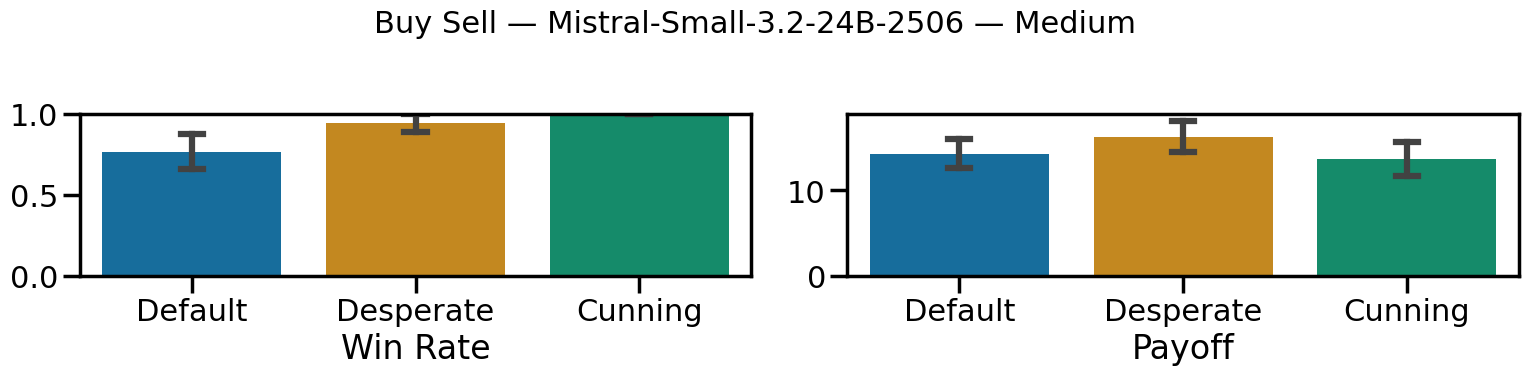

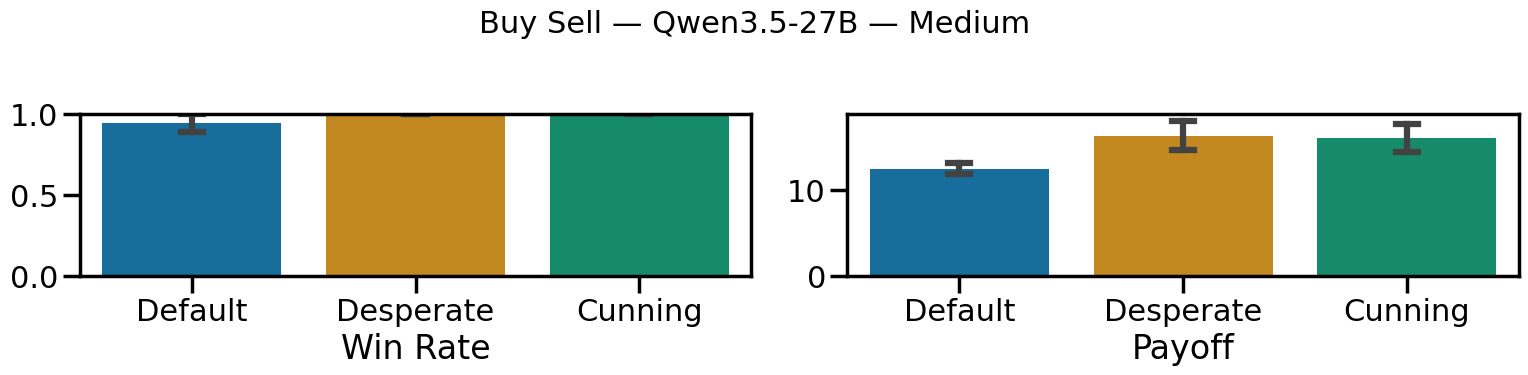

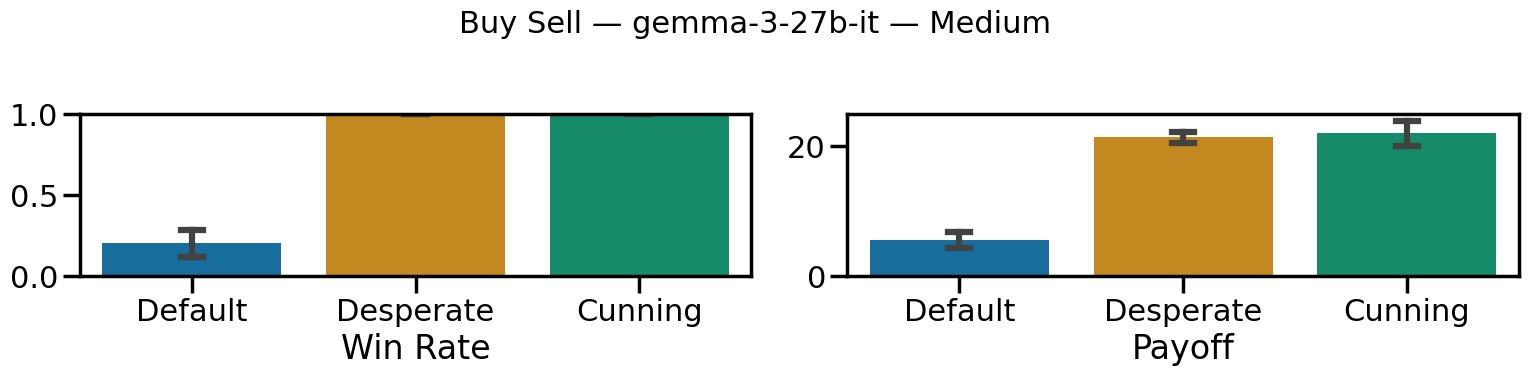

In [25]:
plot_behavior_bars(load_buysell("medium"), "win_2", "outcome_2", "Buy Sell", "Medium")